🚀 HIERARCHICAL CLUSTERING ANALYSIS
📁 Loading and preparing data...
✅ Loaded 2425 rows with 11 columns
🎯 Using 10 columns for clustering: ['Parent_Industry', 'Turnover_Range', 'Employees_Range', 'Job_Seniority', 'Job_Function', 'aoi_1', 'aoi_2', 'aoi_3', 'aoi_4', 'aoi_5']
🆔 Preserved ID columns: ['Unique_ID']
✅ Data preparation complete: (2425, 10)
🌳 Creating dendrogram...
📊 Sampling 100 points for dendrogram visualization


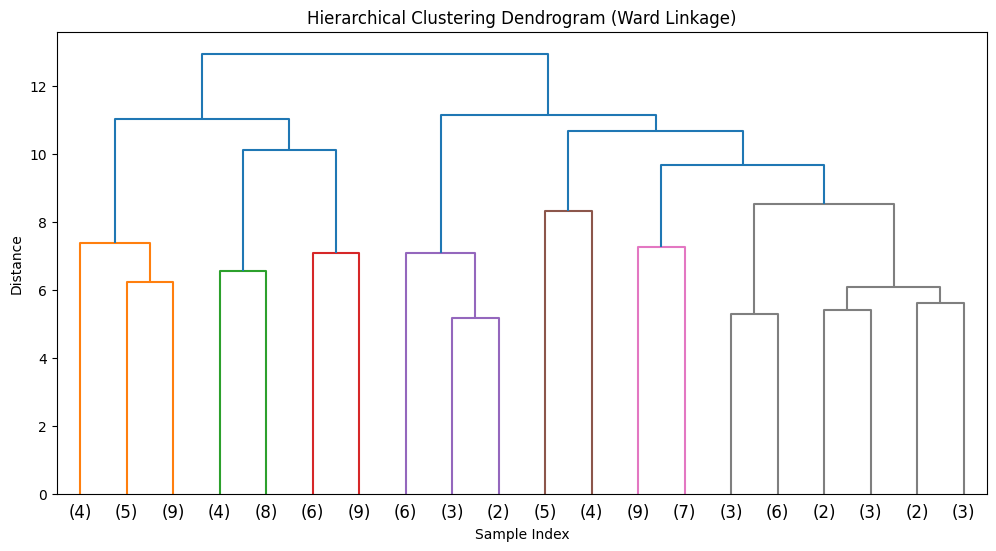

✅ Dendrogram created successfully

🎯 Finding optimal clusters (testing 2 to 10)...
Method         K  Silhouette    Calinski     Davies     Status
---------------------------------------------------------------------------
Ward           2       0.083      164.45      3.524    Success
Ward           3       0.088      172.32      2.990    Success
Ward           4       0.078      171.66      2.740    Success
Ward           5       0.093      175.09      2.506    Success
Ward           6       0.088      173.43      2.316    Success
Ward           7       0.093      169.92      2.137    Success
Ward           8       0.077      165.04      2.053    Success
Ward           9       0.054      156.57      1.995    Success
Ward          10       0.059      147.82      2.087    Success
Complete       2       0.175       35.44      1.760    Success
Complete       3       0.079       77.28      3.414    Success
Complete       4       0.083      110.00      2.623    Success
Complete       5      

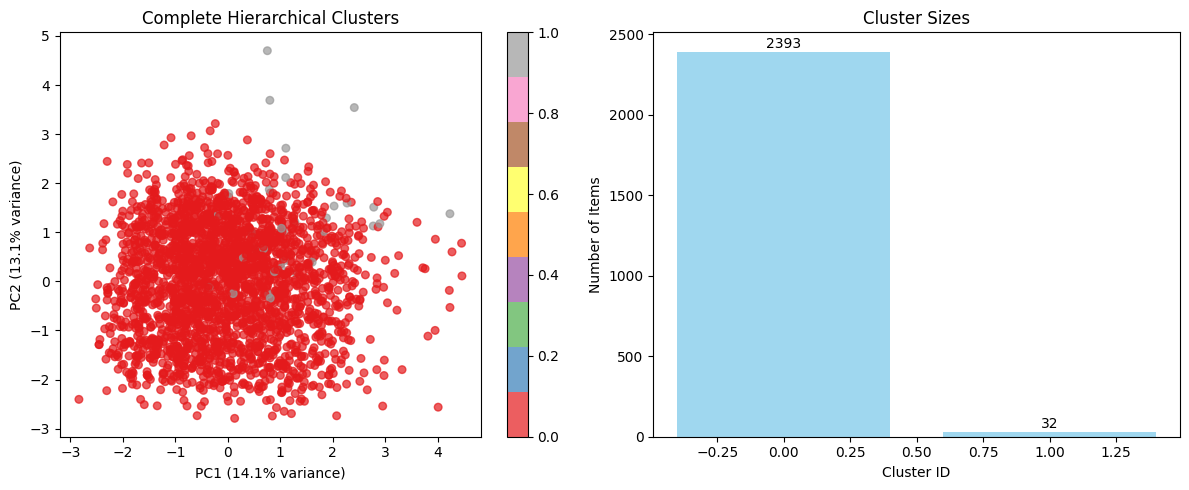


💾 Exporting results to: hierarchical_clustering_results_20250728_163321.xlsx
✅ Results exported successfully!

🎉 HIERARCHICAL CLUSTERING COMPLETE!
✅ 2425 items clustered into 2 hierarchical groups
📁 Results saved to: hierarchical_clustering_results_20250728_163321.xlsx

📋 SAMPLE RESULTS:
Unique_ID  Parent_Industry  Job_Function  hierarchical_cluster
kims_0001                0             0                     0
kims_0002                1             1                     0
kims_0003                2             0                     0
kims_0004                3             1                     0
kims_0005                1             1                     0
kims_0006                4             1                     0
kims_0007                2             2                     0
kims_0008                5             0                     0
kims_0009                1             0                     0
kims_0010                2             0                     0


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class HierarchicalClusteringSystem:
    """
    Complete hierarchical clustering system with robust error handling
    """
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.best_model = None
        self.processed_data = None
        self.linkage_matrix = None
        self.feature_columns = []
        
    def load_and_prepare_data(self, file_path, id_cols=['Unique_ID']):
        """Load and prepare data for hierarchical clustering"""
        
        print("📁 Loading and preparing data...")
        
        # Load data
        df = pd.read_excel(file_path)
        print(f"✅ Loaded {len(df)} rows with {len(df.columns)} columns")
        
        # Separate ID columns from features
        feature_cols = [col for col in df.columns if col not in id_cols]
        self.feature_columns = feature_cols
        
        print(f"🎯 Using {len(feature_cols)} columns for clustering: {feature_cols}")
        print(f"🆔 Preserved ID columns: {id_cols}")
        
        # Encode categorical variables
        processed_df = df.copy()
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                # Handle missing values
                processed_df[col] = processed_df[col].fillna('Unknown')
                # Label encode
                processed_df[col] = pd.factorize(processed_df[col].astype(str))[0]
            else:
                # Fill numeric missing values with median
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        
        # Scale features
        X = processed_df[feature_cols].values
        X_scaled = self.scaler.fit_transform(X)
        
        self.processed_data = processed_df
        
        print(f"✅ Data preparation complete: {X_scaled.shape}")
        return X_scaled, processed_df
    
    def create_dendrogram(self, X_scaled, max_samples=100):
        """Create and display dendrogram with error handling"""
        
        print("🌳 Creating dendrogram...")
        
        try:
            # Sample data if too large for visualization
            if len(X_scaled) > max_samples:
                indices = np.random.choice(len(X_scaled), max_samples, replace=False)
                X_sample = X_scaled[indices]
                print(f"📊 Sampling {max_samples} points for dendrogram visualization")
            else:
                X_sample = X_scaled
                indices = np.arange(len(X_scaled))
            
            # Calculate linkage matrix with ward method (most stable)
            self.linkage_matrix = linkage(X_sample, method='ward')
            
            # Create simple dendrogram
            plt.figure(figsize=(12, 6))
            dendrogram(self.linkage_matrix, truncate_mode='lastp', p=20)
            plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
            plt.xlabel('Sample Index')
            plt.ylabel('Distance')
            plt.show()
            
            print("✅ Dendrogram created successfully")
            
        except Exception as e:
            print(f"⚠️  Could not create dendrogram: {e}")
            print("Continuing with clustering analysis...")
    
    def find_optimal_clusters(self, X_scaled, min_clusters=2, max_clusters=10):
        """Find optimal number of clusters with robust error handling"""
        
        print(f"\n🎯 Finding optimal clusters (testing {min_clusters} to {max_clusters})...")
        
        results = []
        valid_results = 0
        
        # Test different linkage methods (focus on stable ones)
        linkage_methods = ['ward', 'complete']  # Reduced to most stable methods
        
        print(f"{'Method':<12} {'K':>3} {'Silhouette':>11} {'Calinski':>11} {'Davies':>10} {'Status':>10}")
        print("-" * 75)
        
        for method in linkage_methods:
            for k in range(min_clusters, max_clusters + 1):
                try:
                    # Fit hierarchical clustering
                    model = AgglomerativeClustering(
                        n_clusters=k, 
                        linkage=method
                    )
                    
                    labels = model.fit_predict(X_scaled)
                    
                    # Check if we have valid clusters
                    unique_labels = len(set(labels))
                    if unique_labels < 2:
                        print(f"{method.capitalize():<12} {k:>3} {'N/A':>11} {'N/A':>11} {'N/A':>10} {'Failed':>10}")
                        continue
                    
                    # Calculate metrics
                    sil_score = silhouette_score(X_scaled, labels)
                    cal_score = calinski_harabasz_score(X_scaled, labels)
                    dbi_score = davies_bouldin_score(X_scaled, labels)
                    
                    # Quality assessment
                    if sil_score > 0.5:
                        quality = "Excellent"
                    elif sil_score > 0.3:
                        quality = "Good"
                    elif sil_score > 0.2:
                        quality = "Fair"
                    else:
                        quality = "Poor"
                    
                    results.append({
                        'method': method,
                        'k': k,
                        'silhouette': sil_score,
                        'calinski': cal_score,
                        'davies': dbi_score,
                        'quality': quality,
                        'model': model,
                        'labels': labels
                    })
                    
                    valid_results += 1
                    print(f"{method.capitalize():<12} {k:>3} {sil_score:>11.3f} {cal_score:>11.2f} {dbi_score:>10.3f} {'Success':>10}")
                        
                except Exception as e:
                    print(f"{method.capitalize():<12} {k:>3} {'N/A':>11} {'N/A':>11} {'N/A':>10} {'Error':>10}")
                    continue
        
        # FIXED: Check if we have any valid results
        if not results or valid_results == 0:
            print(f"\n❌ No valid clustering configurations found!")
            print("This might happen if:")
            print("- Data has too little variation")
            print("- All features are too similar")
            print("- Scaling issues")
            
            # Create a simple fallback clustering
            print("\n🔄 Creating fallback clustering with K=3...")
            try:
                fallback_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
                fallback_labels = fallback_model.fit_predict(X_scaled)
                
                fallback_config = {
                    'method': 'ward',
                    'k': 3,
                    'silhouette': 0.0,
                    'calinski': 0.0,
                    'davies': 999.0,
                    'quality': 'Fallback',
                    'model': fallback_model,
                    'labels': fallback_labels
                }
                
                print("✅ Fallback clustering created")
                self.best_model = fallback_model
                return fallback_config, [fallback_config]
                
            except Exception as e:
                print(f"❌ Even fallback clustering failed: {e}")
                return None, []
        
        # Find best configuration
        best_config = max(results, key=lambda x: x['silhouette'])
        
        print(f"\n🏆 BEST HIERARCHICAL CONFIGURATION:")
        print(f"   Method: {best_config['method'].upper()} Linkage")
        print(f"   Clusters: {best_config['k']}")
        print(f"   Silhouette Score: {best_config['silhouette']:.3f}")
        print(f"   Quality: {best_config['quality']}")
        
        self.best_model = best_config['model']
        return best_config, results
    
    def analyze_clusters(self, best_config):
        """Analyze the characteristics of each cluster"""
        
        # FIXED: Check if best_config is valid
        if best_config is None:
            print("❌ Cannot analyze clusters - no valid configuration found")
            return {}
        
        labels = best_config['labels']
        
        print(f"\n📊 HIERARCHICAL CLUSTER ANALYSIS:")
        print("=" * 60)
        
        # Add cluster labels to processed data
        self.processed_data['hierarchical_cluster'] = labels
        
        cluster_profiles = {}
        
        for cluster_id in sorted(set(labels)):
            cluster_mask = labels == cluster_id
            cluster_data = self.processed_data[cluster_mask]
            
            cluster_size = len(cluster_data)
            percentage = (cluster_size / len(self.processed_data)) * 100
            
            print(f"\n🏷️  Cluster {cluster_id} - {cluster_size} items ({percentage:.1f}%)")
            
            # Analyze each feature column
            profile = {
                'cluster_id': cluster_id,
                'size': cluster_size,
                'percentage': percentage
            }
            
            for col in self.feature_columns:
                if col in cluster_data.columns:
                    try:
                        if cluster_data[col].dtype in ['int64', 'float64']:
                            # Numerical analysis
                            mean_val = cluster_data[col].mean()
                            print(f"   {col}: {mean_val:.2f} (average)")
                            profile[f'{col}_mean'] = mean_val
                        else:
                            # Categorical analysis - find most common value
                            mode_values = cluster_data[col].mode()
                            if len(mode_values) > 0:
                                print(f"   {col}: {mode_values.iloc[0]} (most common)")
                                profile[f'{col}_mode'] = mode_values.iloc[0]
                    except Exception as e:
                        continue
            
            # Show sample IDs
            if 'Unique_ID' in cluster_data.columns:
                sample_ids = cluster_data['Unique_ID'].head(3).tolist()
                print(f"   Sample IDs: {sample_ids}")
            
            cluster_profiles[cluster_id] = profile
        
        return cluster_profiles
    
    def visualize_clusters(self, X_scaled, best_config):
        """Create cluster visualizations with error handling"""
        
        # FIXED: Check if best_config is valid
        if best_config is None:
            print("⚠️  Cannot create visualizations - no valid configuration found")
            return
        
        print("\n📊 Creating visualizations...")
        
        try:
            labels = best_config['labels']
            
            # Create simple PCA visualization
            from sklearn.decomposition import PCA
            pca = PCA(n_components=2, random_state=42)
            X_pca = pca.fit_transform(X_scaled)
            
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # 1. PCA scatter plot
            scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', alpha=0.7, s=30)
            axes[0].set_title(f'{best_config["method"].capitalize()} Hierarchical Clusters')
            axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
            axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
            plt.colorbar(scatter, ax=axes[0])
            
            # 2. Cluster sizes
            unique, counts = np.unique(labels, return_counts=True)
            bars = axes[1].bar(unique, counts, color='skyblue', alpha=0.8)
            axes[1].set_title('Cluster Sizes')
            axes[1].set_xlabel('Cluster ID')
            axes[1].set_ylabel('Number of Items')
            
            # Add count labels on bars
            for bar, count in zip(bars, counts):
                axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                            str(count), ha='center', va='bottom')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"⚠️  Error creating visualizations: {e}")
    
    def export_results(self, best_config, cluster_profiles, output_filename=None):
        """Export results to Excel with error handling"""
        
        # FIXED: Check if best_config is valid
        if best_config is None:
            print("⚠️  Cannot export results - no valid configuration found")
            return None
        
        if output_filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_filename = f'hierarchical_clustering_results_{timestamp}.xlsx'
        
        print(f"\n💾 Exporting results to: {output_filename}")
        
        try:
            with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
                # Sheet 1: All data with cluster assignments
                self.processed_data.to_excel(writer, sheet_name='Data_with_Clusters', index=False)
                
                # Sheet 2: Cluster profiles
                if cluster_profiles:
                    profiles_df = pd.DataFrame(list(cluster_profiles.values()))
                    profiles_df.to_excel(writer, sheet_name='Cluster_Profiles', index=False)
                
                # Sheet 3: Clustering configuration
                config_info = [{
                    'Parameter': 'Method',
                    'Value': best_config['method']
                }, {
                    'Parameter': 'Number_of_Clusters',
                    'Value': best_config['k']
                }, {
                    'Parameter': 'Silhouette_Score',
                    'Value': best_config['silhouette']
                }, {
                    'Parameter': 'Quality_Assessment',
                    'Value': best_config['quality']
                }]
                
                config_df = pd.DataFrame(config_info)
                config_df.to_excel(writer, sheet_name='Configuration', index=False)
            
            print(f"✅ Results exported successfully!")
            return output_filename
            
        except Exception as e:
            print(f"⚠️  Error exporting results: {e}")
            return None

# Main execution function with error handling
def hierarchical_clustering_analysis(file_path, id_cols=['Unique_ID']):
    """
    Complete hierarchical clustering analysis pipeline with robust error handling
    """
    
    print("🚀 HIERARCHICAL CLUSTERING ANALYSIS")
    print("=" * 50)
    
    try:
        # Initialize system
        hc_system = HierarchicalClusteringSystem()
        
        # Load and prepare data
        X_scaled, processed_df = hc_system.load_and_prepare_data(file_path, id_cols)
        
        # Create dendrogram
        linkage_results = hc_system.create_dendrogram(X_scaled)
        
        # Find optimal clusters
        best_config, all_results = hc_system.find_optimal_clusters(X_scaled)
        
        # Check if we got valid results
        if best_config is None:
            print("❌ Hierarchical clustering analysis failed completely")
            return None, None, None
        
        # Analyze clusters
        cluster_profiles = hc_system.analyze_clusters(best_config)
        
        # Create visualizations
        hc_system.visualize_clusters(X_scaled, best_config)
        
        # Export results
        output_file = hc_system.export_results(best_config, cluster_profiles)
        
        print(f"\n🎉 HIERARCHICAL CLUSTERING COMPLETE!")
        print(f"✅ {len(processed_df)} items clustered into {best_config['k']} hierarchical groups")
        if output_file:
            print(f"📁 Results saved to: {output_file}")
        
        return hc_system, best_config, output_file
        
    except Exception as e:
        print(f"❌ Error in hierarchical clustering analysis: {e}")
        return None, None, None

# Usage with your data
if __name__ == "__main__":
    # Run hierarchical clustering on your friend data
    result = hierarchical_clustering_analysis('./las3.18.xlsx')
    
    if result[0] is not None:
        hc_system, best_config, output_file = result
        
        # Show sample results
        print(f"\n📋 SAMPLE RESULTS:")
        sample_cols = ['Unique_ID', 'Parent_Industry', 'Job_Function', 'hierarchical_cluster']
        available_cols = [col for col in sample_cols if col in hc_system.processed_data.columns]
        print(hc_system.processed_data[available_cols].head(10).to_string(index=False))
    else:
        print("❌ Clustering analysis failed - please check your data")



🚀 COMPREHENSIVE CLUSTERING EVALUATION
📁 Loading and preparing data in multiple formats...
✅ Loaded 2425 rows with 10 feature columns
🔧 Creating scaled data representation...
✅ Scaled data shape: (2425, 10)
🔄 Creating embedded data representation...


Batches: 100%|██████████| 76/76 [00:40<00:00,  1.90it/s]


✅ Embedded data shape: (2425, 384)
📊 Creating scaled embedded data...
✅ Embedded scaled data shape: (2425, 384)
🎯 Creating dimensionally reduced embedded data (10-30 dims)...
   ✅ Reduced to 10 dimensions: (2425, 10)
   ✅ Reduced to 15 dimensions: (2425, 15)
   ✅ Reduced to 20 dimensions: (2425, 20)
   ✅ Reduced to 25 dimensions: (2425, 25)
   ✅ Reduced to 30 dimensions: (2425, 30)

🔍 Evaluating clustering methods on 8 data representations...
Data Type                 Method          K/Config  Silhouette    Calinski     Davies    Quality
----------------------------------------------------------------------------------------------------

--- Processing scaled ---
scaled                    kmeans                 2       0.108      255.89      2.997       Poor
scaled                    kmeans                 3       0.092      235.94      2.602       Poor
scaled                    kmeans                 4       0.102      228.08      2.391       Poor
scaled                    kmeans     

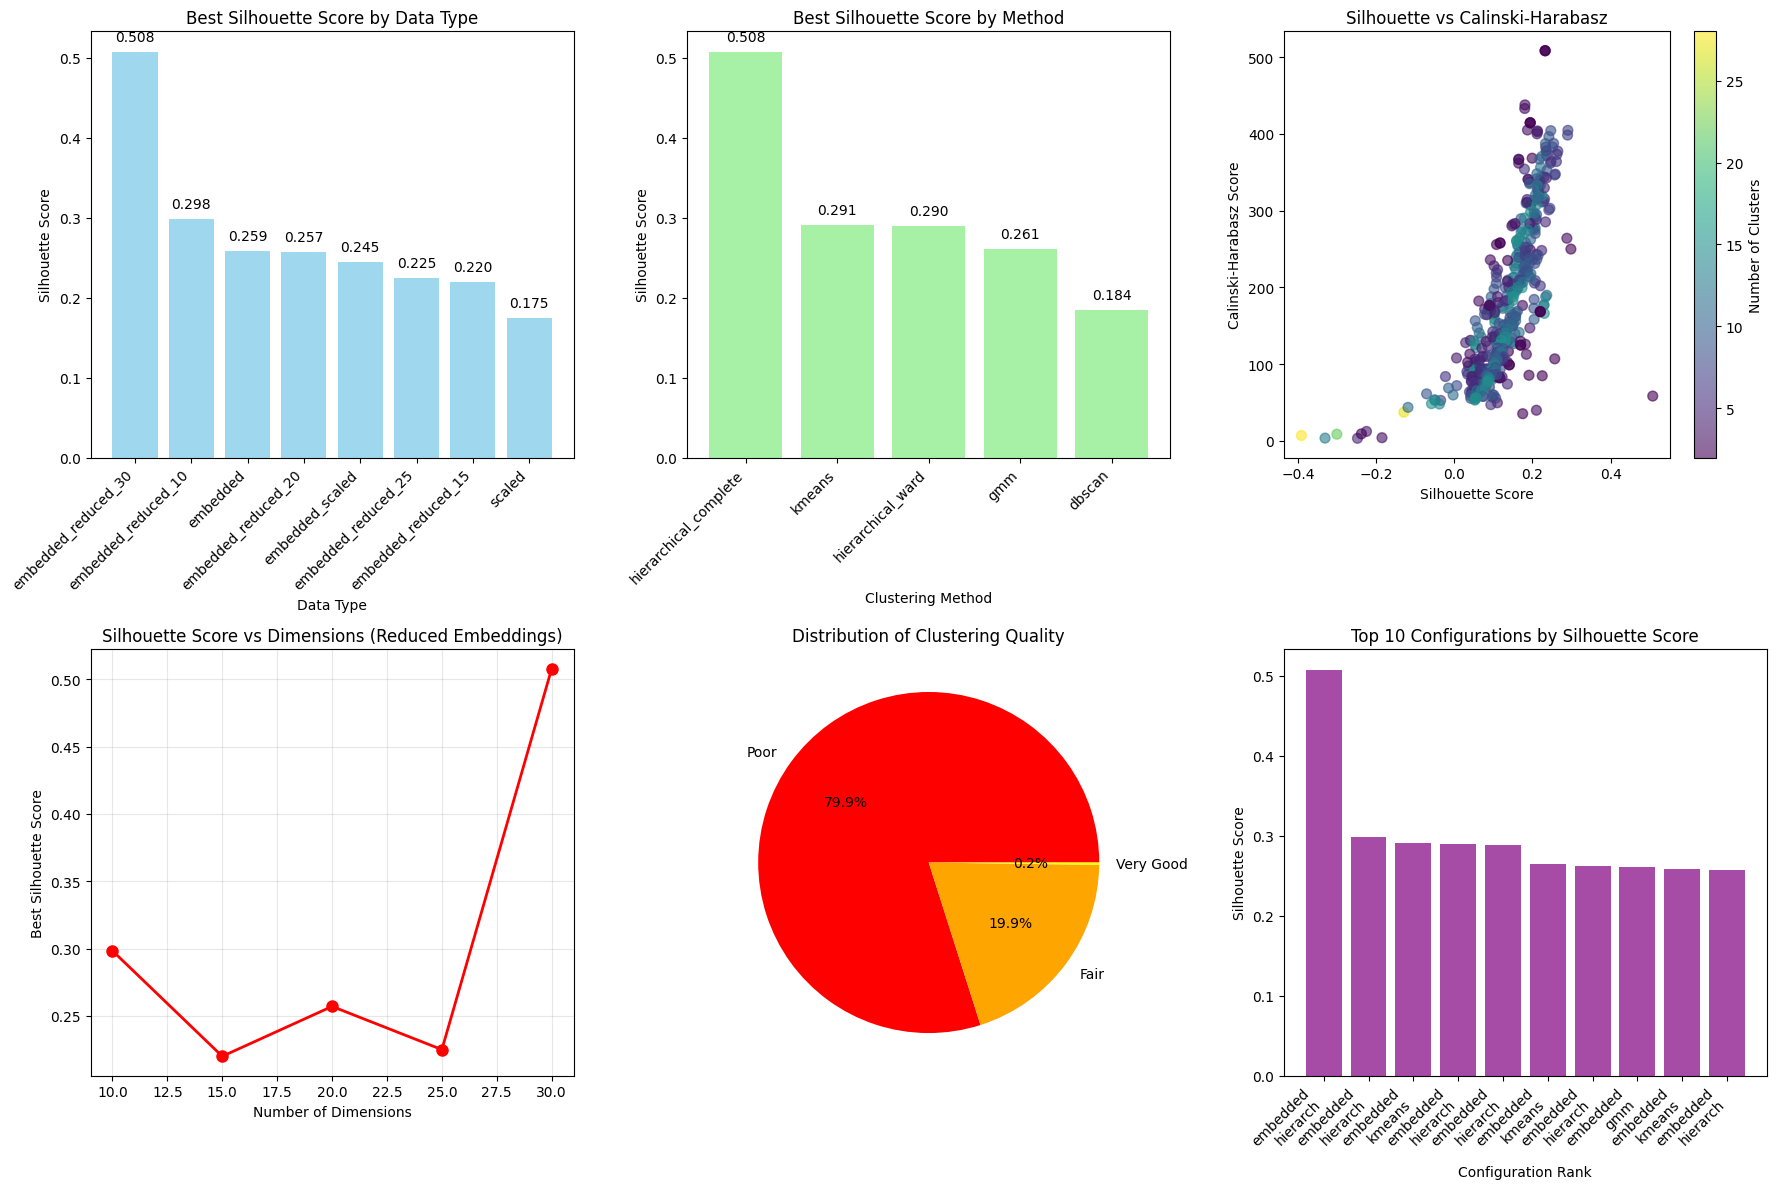


💾 Exporting comprehensive results to: comprehensive_clustering_evaluation_20250728_165546.xlsx
✅ Comprehensive results exported successfully!

🎉 COMPREHENSIVE EVALUATION COMPLETE!
✅ Tested 448 different configurations
📊 Best Silhouette Score: 0.5078
📁 Results saved to: comprehensive_clustering_evaluation_20250728_165546.xlsx

📋 TOP 5 CONFIGURATIONS BY SILHOUETTE SCORE:
          data_type                method config  silhouette   calinski   davies   quality
embedded_reduced_30 hierarchical_complete    k=2    0.507796  58.427551 0.684898 Very Good
embedded_reduced_10 hierarchical_complete    k=2    0.298348 249.988921 1.109467      Fair
embedded_reduced_10                kmeans    k=7    0.290646 404.718277 1.296128      Fair
embedded_reduced_10     hierarchical_ward    k=7    0.289928 398.495660 1.286674      Fair
embedded_reduced_10 hierarchical_complete    k=3    0.288033 264.073759 1.153621      Fair


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA, TruncatedSVD
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class ComprehensiveClusteringEvaluator:
    """
    Comprehensive clustering evaluator that tests multiple data representations
    and finds the best silhouette and other scores
    """
    
    def __init__(self):
        self.results = []
        self.best_configs = {}
        self.data_representations = {}
        
    def load_and_prepare_data(self, file_path, id_cols=['Unique_ID']):
        """Load and prepare data in multiple formats"""
        
        print("📁 Loading and preparing data in multiple formats...")
        
        # Load original data
        df = pd.read_excel(file_path)
        feature_cols = [col for col in df.columns if col not in id_cols]
        
        print(f"✅ Loaded {len(df)} rows with {len(feature_cols)} feature columns")
        
        self.original_data = df
        self.feature_cols = feature_cols
        
        return df, feature_cols
    
    def create_scaled_data(self, df, feature_cols):
        """Create traditional scaled data (label encoded + scaled)"""
        
        print("🔧 Creating scaled data representation...")
        
        # Encode categorical variables
        processed_df = df.copy()
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                processed_df[col] = processed_df[col].fillna('Unknown')
                processed_df[col] = pd.factorize(processed_df[col].astype(str))[0]
            else:
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(processed_df[feature_cols].values)
        
        self.data_representations['scaled'] = X_scaled
        print(f"✅ Scaled data shape: {X_scaled.shape}")
        
        return X_scaled
    
    def create_embedded_data(self, df):
        """Create embedded data representation"""
        
        print("🔄 Creating embedded data representation...")
        
        # Create rich text descriptions
        text_data = []
        for _, row in df.iterrows():
            text = f"Professional in {row['Parent_Industry']} industry with {row['Turnover_Range']} revenue and {row['Employees_Range']} employees, working as {row['Job_Function']} at {row['Job_Seniority']} level, interested in {row['aoi_1']}, {row['aoi_2']}, {row['aoi_3']}, {row['aoi_4']}, {row['aoi_5']}"
            text_data.append(text)
        
        # Generate embeddings
        model = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = model.encode(text_data, show_progress_bar=True)
        
        self.data_representations['embedded'] = embeddings
        print(f"✅ Embedded data shape: {embeddings.shape}")
        
        return embeddings
    
    def create_embedded_scaled_data(self, embeddings):
        """Scale the embedded data"""
        
        print("📊 Creating scaled embedded data...")
        
        scaler = StandardScaler()
        embedded_scaled = scaler.fit_transform(embeddings)
        
        self.data_representations['embedded_scaled'] = embedded_scaled
        print(f"✅ Embedded scaled data shape: {embedded_scaled.shape}")
        
        return embedded_scaled
    
    def create_reduced_embedded_data(self, embeddings, dimensions_range=(10, 30)):
        """Create dimensionally reduced embedded data"""
        
        print(f"🎯 Creating dimensionally reduced embedded data ({dimensions_range[0]}-{dimensions_range[1]} dims)...")
        
        reduced_data = {}
        
        # Test different dimension reductions
        for n_dims in range(dimensions_range[0], dimensions_range[1] + 1, 5):
            # Use PCA for dimensionality reduction
            pca = PCA(n_components=n_dims, random_state=42)
            embedded_reduced = pca.fit_transform(embeddings)
            
            # Scale the reduced data
            scaler = StandardScaler()
            embedded_reduced_scaled = scaler.fit_transform(embedded_reduced)
            
            reduced_data[f'embedded_reduced_{n_dims}'] = embedded_reduced_scaled
            
            print(f"   ✅ Reduced to {n_dims} dimensions: {embedded_reduced_scaled.shape}")
        
        self.data_representations.update(reduced_data)
        return reduced_data
    
    def evaluate_clustering_methods(self, data_dict, method_configs=None):
        """Evaluate multiple clustering methods on all data representations"""
        
        if method_configs is None:
            method_configs = {
                'kmeans': {'k_range': range(2, 16)},
                'gmm': {'k_range': range(2, 16)},
                'hierarchical_ward': {'k_range': range(2, 16)},
                'hierarchical_complete': {'k_range': range(2, 16)},
                'dbscan': {'eps_range': [0.3, 0.5, 0.7, 1.0], 'min_samples': [5, 10]}
            }
        
        print(f"\n🔍 Evaluating clustering methods on {len(data_dict)} data representations...")
        print(f"{'Data Type':<25} {'Method':<15} {'K/Config':>8} {'Silhouette':>11} {'Calinski':>11} {'Davies':>10} {'Quality':>10}")
        print("-" * 100)
        
        for data_name, X in data_dict.items():
            print(f"\n--- Processing {data_name} ---")
            
            for method_name, config in method_configs.items():
                if method_name == 'dbscan':
                    self._evaluate_dbscan(data_name, X, method_name, config)
                else:
                    self._evaluate_k_based_methods(data_name, X, method_name, config)
        
        return self.results
    
    def _evaluate_k_based_methods(self, data_name, X, method_name, config):
        """Evaluate methods that require specifying number of clusters"""
        
        for k in config['k_range']:
            try:
                # Fit clustering model
                if method_name == 'kmeans':
                    model = KMeans(n_clusters=k, n_init=20, random_state=42)
                    labels = model.fit_predict(X)
                elif method_name == 'gmm':
                    model = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
                    labels = model.fit_predict(X)
                elif method_name == 'hierarchical_ward':
                    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
                    labels = model.fit_predict(X)
                elif method_name == 'hierarchical_complete':
                    model = AgglomerativeClustering(n_clusters=k, linkage='complete')
                    labels = model.fit_predict(X)
                
                # Calculate metrics
                if len(set(labels)) >= 2:
                    sil_score = silhouette_score(X, labels)
                    cal_score = calinski_harabasz_score(X, labels)
                    dbi_score = davies_bouldin_score(X, labels)
                    
                    # Quality assessment
                    if sil_score > 0.7:
                        quality = "Excellent"
                    elif sil_score > 0.5:
                        quality = "Very Good"
                    elif sil_score > 0.3:
                        quality = "Good"
                    elif sil_score > 0.2:
                        quality = "Fair"
                    else:
                        quality = "Poor"
                    
                    result = {
                        'data_type': data_name,
                        'method': method_name,
                        'k': k,
                        'config': f'k={k}',
                        'silhouette': sil_score,
                        'calinski': cal_score,
                        'davies': dbi_score,
                        'quality': quality,
                        'model': model,
                        'labels': labels,
                        'data_shape': X.shape
                    }
                    
                    self.results.append(result)
                    
                    print(f"{data_name:<25} {method_name:<15} {k:>8} {sil_score:>11.3f} {cal_score:>11.2f} {dbi_score:>10.3f} {quality:>10}")
                
            except Exception as e:
                continue
    
    def _evaluate_dbscan(self, data_name, X, method_name, config):
        """Evaluate DBSCAN with different parameters"""
        
        for eps in config['eps_range']:
            for min_samples in config['min_samples']:
                try:
                    model = DBSCAN(eps=eps, min_samples=min_samples)
                    labels = model.fit_predict(X)
                    
                    # Check if we have valid clusters
                    unique_labels = len(set(labels)) - (1 if -1 in labels else 0)
                    if unique_labels >= 2:
                        sil_score = silhouette_score(X, labels)
                        cal_score = calinski_harabasz_score(X, labels)
                        dbi_score = davies_bouldin_score(X, labels)
                        
                        quality = "Excellent" if sil_score > 0.7 else "Very Good" if sil_score > 0.5 else "Good" if sil_score > 0.3 else "Fair" if sil_score > 0.2 else "Poor"
                        
                        result = {
                            'data_type': data_name,
                            'method': method_name,
                            'k': unique_labels,
                            'config': f'eps={eps},ms={min_samples}',
                            'silhouette': sil_score,
                            'calinski': cal_score,
                            'davies': dbi_score,
                            'quality': quality,
                            'model': model,
                            'labels': labels,
                            'data_shape': X.shape
                        }
                        
                        self.results.append(result)
                        
                        print(f"{data_name:<25} {method_name:<15} {f'eps={eps}':>8} {sil_score:>11.3f} {cal_score:>11.2f} {dbi_score:>10.3f} {quality:>10}")
                
                except Exception as e:
                    continue
    
    def find_best_configurations(self):
        """Find best configurations for each metric"""
        
        if not self.results:
            print("❌ No results to analyze")
            return None
        
        print(f"\n🏆 FINDING BEST CONFIGURATIONS FROM {len(self.results)} RESULTS...")
        
        # Convert results to DataFrame for easier analysis
        results_df = pd.DataFrame(self.results)
        
        # Find best configurations for each metric
        best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
        best_calinski = results_df.loc[results_df['calinski'].idxmax()]
        best_davies = results_df.loc[results_df['davies'].idxmin()]  # Lower is better for Davies-Bouldin
        
        # Find overall best (weighted score)
        results_df['weighted_score'] = (
            0.5 * results_df['silhouette'] + 
            0.3 * (results_df['calinski'] / results_df['calinski'].max()) + 
            0.2 * (1 - results_df['davies'] / results_df['davies'].max())
        )
        best_overall = results_df.loc[results_df['weighted_score'].idxmax()]
        
        self.best_configs = {
            'silhouette': best_silhouette,
            'calinski': best_calinski,
            'davies': best_davies,
            'overall': best_overall
        }
        
        # Display results
        print(f"\n🥇 BEST SILHOUETTE SCORE: {best_silhouette['silhouette']:.4f}")
        print(f"   Data Type: {best_silhouette['data_type']}")
        print(f"   Method: {best_silhouette['method']}")
        print(f"   Config: {best_silhouette['config']}")
        print(f"   Quality: {best_silhouette['quality']}")
        
        print(f"\n🥇 BEST CALINSKI-HARABASZ SCORE: {best_calinski['calinski']:.2f}")
        print(f"   Data Type: {best_calinski['data_type']}")
        print(f"   Method: {best_calinski['method']}")
        print(f"   Config: {best_calinski['config']}")
        
        print(f"\n🥇 BEST DAVIES-BOULDIN SCORE: {best_davies['davies']:.4f}")
        print(f"   Data Type: {best_davies['data_type']}")
        print(f"   Method: {best_davies['method']}")
        print(f"   Config: {best_davies['config']}")
        
        print(f"\n🏆 BEST OVERALL CONFIGURATION:")
        print(f"   Data Type: {best_overall['data_type']}")
        print(f"   Method: {best_overall['method']}")
        print(f"   Config: {best_overall['config']}")
        print(f"   Silhouette: {best_overall['silhouette']:.4f}")
        print(f"   Calinski-Harabasz: {best_overall['calinski']:.2f}")
        print(f"   Davies-Bouldin: {best_overall['davies']:.4f}")
        print(f"   Weighted Score: {best_overall['weighted_score']:.4f}")
        
        return self.best_configs, results_df
    
    def visualize_results(self, results_df):
        """Create comprehensive visualizations of results"""
        
        print("\n📊 Creating comprehensive visualizations...")
        
        # Create subplots
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Silhouette scores by data type
        silhouette_by_data = results_df.groupby('data_type')['silhouette'].max().sort_values(ascending=False)
        bars1 = axes[0,0].bar(range(len(silhouette_by_data)), silhouette_by_data.values, color='skyblue', alpha=0.8)
        axes[0,0].set_title('Best Silhouette Score by Data Type')
        axes[0,0].set_xlabel('Data Type')
        axes[0,0].set_ylabel('Silhouette Score')
        axes[0,0].set_xticks(range(len(silhouette_by_data)))
        axes[0,0].set_xticklabels(silhouette_by_data.index, rotation=45, ha='right')
        
        # Add value labels on bars
        for bar, value in zip(bars1, silhouette_by_data.values):
            axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                          f'{value:.3f}', ha='center', va='bottom')
        
        # 2. Silhouette scores by method
        silhouette_by_method = results_df.groupby('method')['silhouette'].max().sort_values(ascending=False)
        bars2 = axes[0,1].bar(range(len(silhouette_by_method)), silhouette_by_method.values, color='lightgreen', alpha=0.8)
        axes[0,1].set_title('Best Silhouette Score by Method')
        axes[0,1].set_xlabel('Clustering Method')
        axes[0,1].set_ylabel('Silhouette Score')
        axes[0,1].set_xticks(range(len(silhouette_by_method)))
        axes[0,1].set_xticklabels(silhouette_by_method.index, rotation=45, ha='right')
        
        for bar, value in zip(bars2, silhouette_by_method.values):
            axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                          f'{value:.3f}', ha='center', va='bottom')
        
        # 3. Scatter plot: Silhouette vs Calinski-Harabasz
        scatter = axes[0,2].scatter(results_df['silhouette'], results_df['calinski'], 
                                   c=results_df['k'], cmap='viridis', alpha=0.6, s=50)
        axes[0,2].set_title('Silhouette vs Calinski-Harabasz')
        axes[0,2].set_xlabel('Silhouette Score')
        axes[0,2].set_ylabel('Calinski-Harabasz Score')
        plt.colorbar(scatter, ax=axes[0,2], label='Number of Clusters')
        
        # 4. Dimensionality effect (for embedded reduced data)
        reduced_data_results = results_df[results_df['data_type'].str.contains('embedded_reduced')]
        if not reduced_data_results.empty:
            reduced_data_results['dimensions'] = reduced_data_results['data_type'].str.extract('(\d+)').astype(int)
            dim_scores = reduced_data_results.groupby('dimensions')['silhouette'].max()
            axes[1,0].plot(dim_scores.index, dim_scores.values, 'o-', color='red', linewidth=2, markersize=8)
            axes[1,0].set_title('Silhouette Score vs Dimensions (Reduced Embeddings)')
            axes[1,0].set_xlabel('Number of Dimensions')
            axes[1,0].set_ylabel('Best Silhouette Score')
            axes[1,0].grid(True, alpha=0.3)
        
        # 5. Quality distribution
        quality_counts = results_df['quality'].value_counts()
        colors = ['red', 'orange', 'yellow', 'lightgreen', 'green'][:len(quality_counts)]
        wedges, texts, autotexts = axes[1,1].pie(quality_counts.values, labels=quality_counts.index, 
                                                 autopct='%1.1f%%', colors=colors)
        axes[1,1].set_title('Distribution of Clustering Quality')
        
        # 6. Best results comparison
        top_10_results = results_df.nlargest(10, 'silhouette')
        x_pos = range(len(top_10_results))
        bars6 = axes[1,2].bar(x_pos, top_10_results['silhouette'], color='purple', alpha=0.7)
        axes[1,2].set_title('Top 10 Configurations by Silhouette Score')
        axes[1,2].set_xlabel('Configuration Rank')
        axes[1,2].set_ylabel('Silhouette Score')
        axes[1,2].set_xticks(x_pos)
        axes[1,2].set_xticklabels([f"{row['data_type'][:8]}\n{row['method'][:8]}" 
                                  for _, row in top_10_results.iterrows()], rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    def export_comprehensive_results(self, results_df, output_filename=None):
        """Export all results to Excel"""
        
        if output_filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_filename = f'comprehensive_clustering_evaluation_{timestamp}.xlsx'
        
        print(f"\n💾 Exporting comprehensive results to: {output_filename}")
        
        with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
            # All results
            results_df.drop(['model', 'labels'], axis=1).to_excel(writer, sheet_name='All_Results', index=False)
            
            # Best configurations
            best_configs_df = pd.DataFrame([
                {'Metric': 'Best_Silhouette', 'Data_Type': self.best_configs['silhouette']['data_type'],
                 'Method': self.best_configs['silhouette']['method'], 'Config': self.best_configs['silhouette']['config'],
                 'Score': self.best_configs['silhouette']['silhouette']},
                {'Metric': 'Best_Calinski', 'Data_Type': self.best_configs['calinski']['data_type'],
                 'Method': self.best_configs['calinski']['method'], 'Config': self.best_configs['calinski']['config'],
                 'Score': self.best_configs['calinski']['calinski']},
                {'Metric': 'Best_Davies', 'Data_Type': self.best_configs['davies']['data_type'],
                 'Method': self.best_configs['davies']['method'], 'Config': self.best_configs['davies']['config'],
                 'Score': self.best_configs['davies']['davies']},
                {'Metric': 'Best_Overall', 'Data_Type': self.best_configs['overall']['data_type'],
                 'Method': self.best_configs['overall']['method'], 'Config': self.best_configs['overall']['config'],
                 'Score': self.best_configs['overall']['weighted_score']}
            ])
            best_configs_df.to_excel(writer, sheet_name='Best_Configurations', index=False)
            
            # Summary by data type
            summary_by_data = results_df.groupby('data_type').agg({
                'silhouette': ['max', 'mean', 'std'],
                'calinski': ['max', 'mean', 'std'],
                'davies': ['min', 'mean', 'std']
            }).round(4)
            summary_by_data.to_excel(writer, sheet_name='Summary_by_Data_Type')
            
            # Summary by method
            summary_by_method = results_df.groupby('method').agg({
                'silhouette': ['max', 'mean', 'std'],
                'calinski': ['max', 'mean', 'std'],
                'davies': ['min', 'mean', 'std']
            }).round(4)
            summary_by_method.to_excel(writer, sheet_name='Summary_by_Method')
        
        print(f"✅ Comprehensive results exported successfully!")
        return output_filename

# Main execution function
def comprehensive_clustering_evaluation(file_path):
    """
    Complete evaluation pipeline that tests all data representations
    and finds the best clustering configurations
    """
    
    print("🚀 COMPREHENSIVE CLUSTERING EVALUATION")
    print("=" * 50)
    
    # Initialize evaluator
    evaluator = ComprehensiveClusteringEvaluator()
    
    # Load and prepare data
    df, feature_cols = evaluator.load_and_prepare_data(file_path)
    
    # Create all data representations
    X_scaled = evaluator.create_scaled_data(df, feature_cols)
    embeddings = evaluator.create_embedded_data(df)
    embedded_scaled = evaluator.create_embedded_scaled_data(embeddings)
    reduced_embedded = evaluator.create_reduced_embedded_data(embeddings, (10, 30))
    
    # Evaluate all clustering methods on all data representations
    results = evaluator.evaluate_clustering_methods(evaluator.data_representations)
    
    # Find best configurations
    best_configs, results_df = evaluator.find_best_configurations()
    
    # Create visualizations
    evaluator.visualize_results(results_df)
    
    # Export results
    output_file = evaluator.export_comprehensive_results(results_df)
    
    print(f"\n🎉 COMPREHENSIVE EVALUATION COMPLETE!")
    print(f"✅ Tested {len(results)} different configurations")
    print(f"📊 Best Silhouette Score: {best_configs['silhouette']['silhouette']:.4f}")
    print(f"📁 Results saved to: {output_file}")
    
    return evaluator, best_configs, results_df

# Run comprehensive evaluation
if __name__ == "__main__":
    evaluator, best_configs, results_df = comprehensive_clustering_evaluation('./las3.18.xlsx')
    
    # Show top 5 configurations
    print(f"\n📋 TOP 5 CONFIGURATIONS BY SILHOUETTE SCORE:")
    top_5 = results_df.nlargest(5, 'silhouette')[['data_type', 'method', 'config', 'silhouette', 'calinski', 'davies', 'quality']]
    print(top_5.to_string(index=False))


🚀 IMPROVED HIERARCHICAL COMPLETE LINKAGE CLUSTERING
📁 Loading and analyzing data structure...
✅ Loaded 2425 friends with 10 features

🔍 Data Characteristics Analysis:
   Parent_Industry: 15 unique categorical values
   Turnover_Range: 8 unique categorical values
   Employees_Range: 7 unique categorical values
   Job_Seniority: 6 unique categorical values
   Job_Function: 21 unique categorical values
   aoi_1: 17 unique categorical values
   aoi_2: 19 unique categorical values
   aoi_3: 19 unique categorical values
   aoi_4: 20 unique categorical values
   aoi_5: 20 unique categorical values

📊 Summary: 10 categorical, 0 numerical columns

⚖️  Categorical Distribution Analysis:
   Parent_Industry: Most common 'Information & Technology' (1038) - Imbalance ratio: 2.75
   Turnover_Range: Most common '51 to 100 Crs' (523) - Imbalance ratio: 1.18
   Employees_Range: Most common '10000+ Emp' (583) - Imbalance ratio: 1.18

🔧 Creating advanced preprocessing strategies...
   ✅ enhanced_categoric

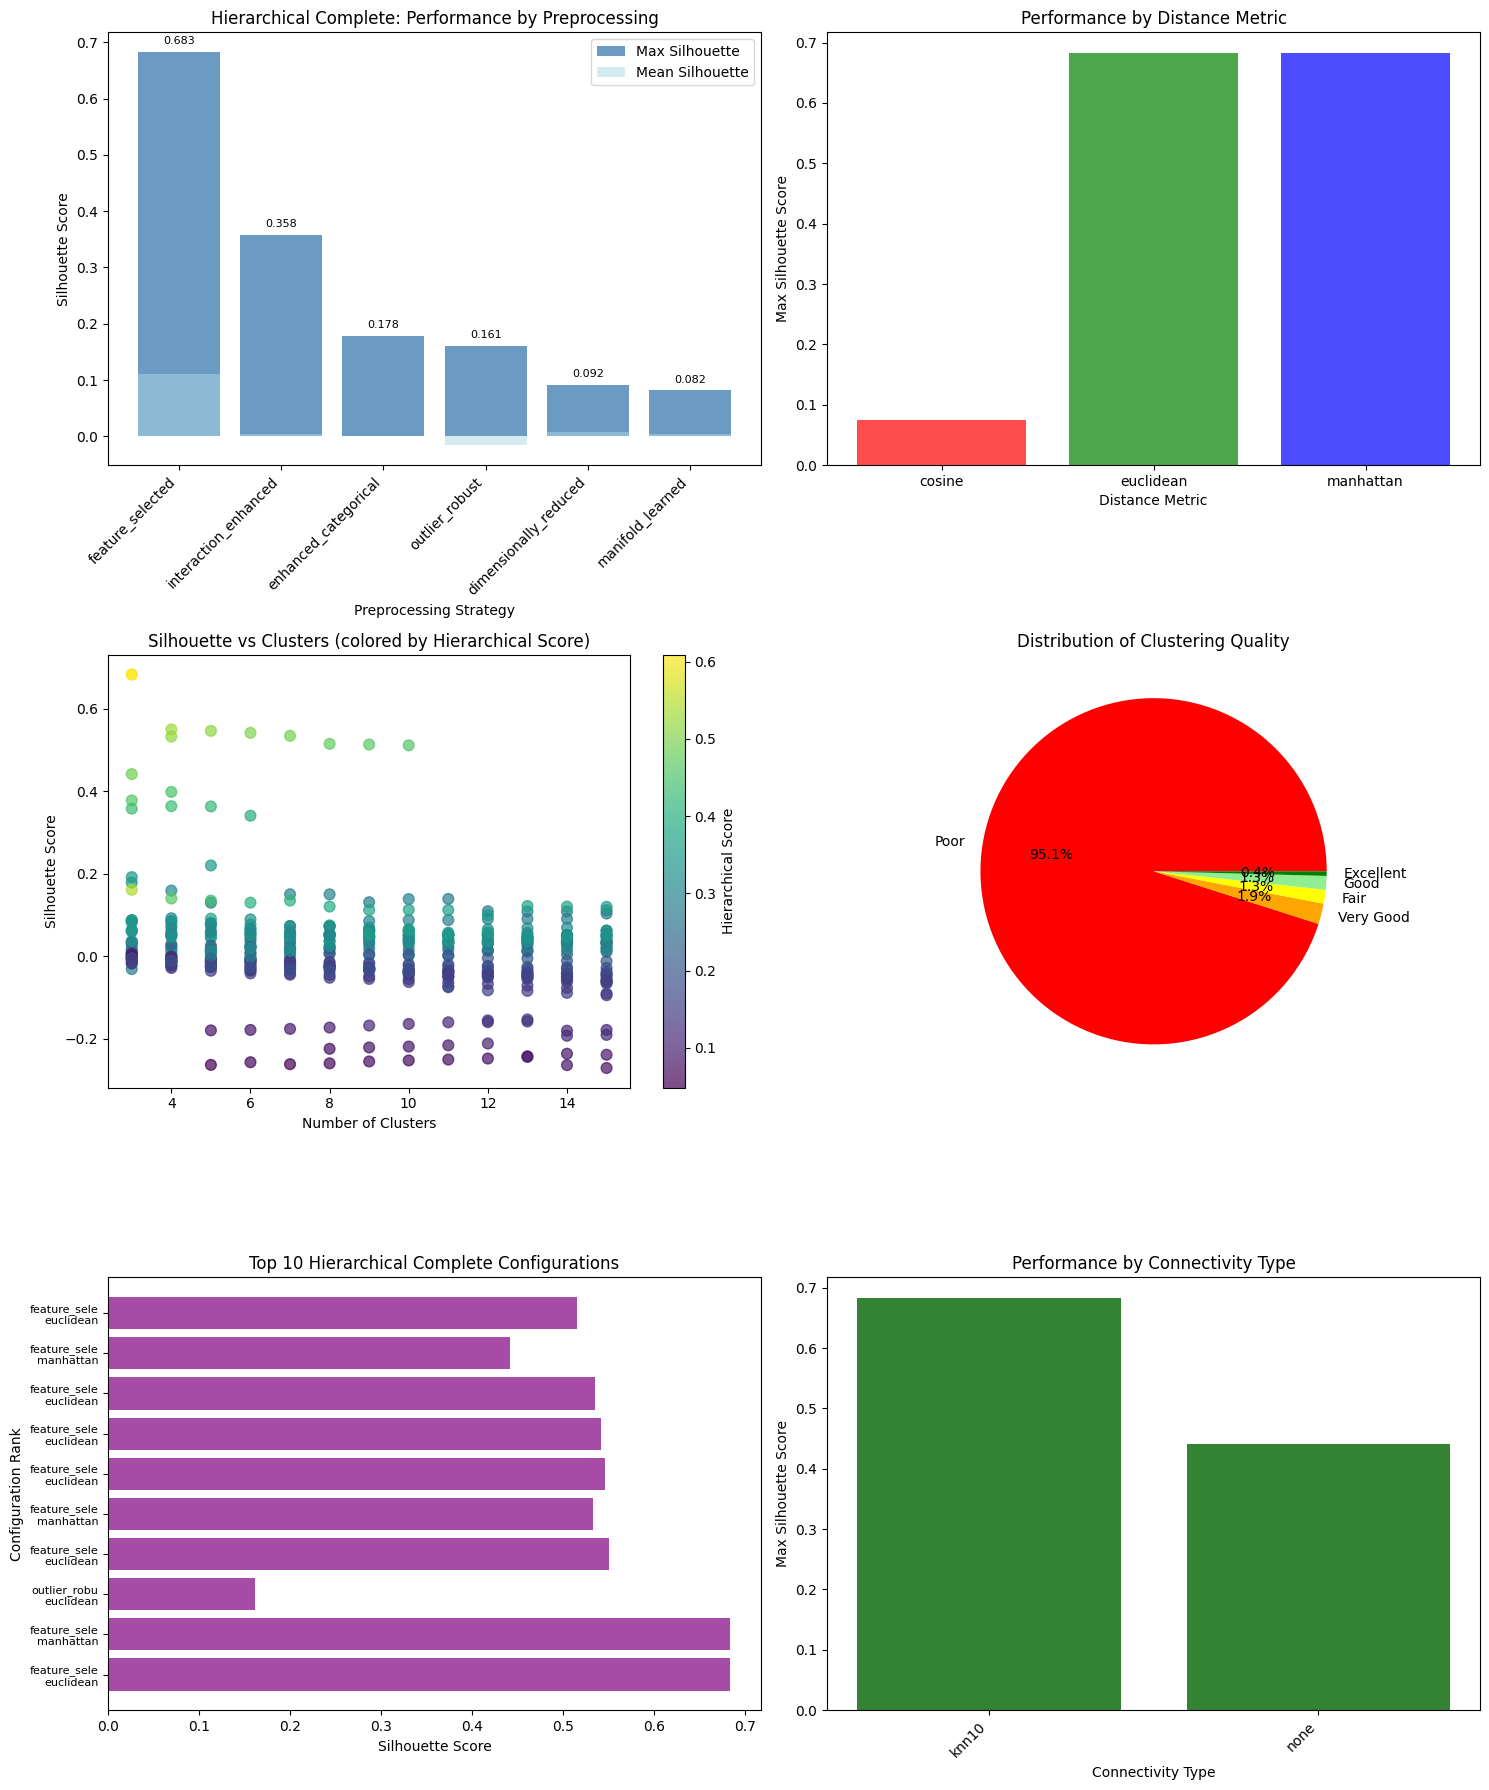


💾 Exporting hierarchical complete results to: improved_hierarchical_complete_20250728_171408.xlsx
✅ Hierarchical complete clustering results exported successfully!

🎉 IMPROVED HIERARCHICAL COMPLETE CLUSTERING COMPLETE!
✅ Tested 468 different configurations
🏆 Best Silhouette Score: 0.6828
📈 Improvement over original (0.175): 3.90x
🎯 Best Configuration Clusters: 3
📁 Results saved to: improved_hierarchical_complete_20250728_171408.xlsx

📋 TOP 5 IMPROVED HIERARCHICAL COMPLETE CONFIGURATIONS:
       data_type distance_metric connectivity  k  silhouette  hierarchical_score   quality
feature_selected       euclidean        knn10  3    0.682766            0.608876 Excellent
feature_selected       manhattan        knn10  3    0.682766            0.608876 Excellent
  outlier_robust       euclidean         none  3    0.160959            0.539963      Fair
feature_selected       euclidean        knn10  4    0.549717            0.526756 Very Good
feature_selected       manhattan        knn10  4   

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA, FastICA, TruncatedSVD
from sklearn.manifold import LocallyLinearEmbedding, Isomap
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class AdvancedHierarchicalCompleteSystem:
    """
    Advanced Hierarchical Complete Linkage Clustering System
    Specifically designed to improve cluster separation and discover unique clusters
    """
    
    def __init__(self):
        self.preprocessors = {}
        self.models = {}
        self.results = []
        self.best_configuration = None
        self.original_data = None
        
    def load_and_analyze_data(self, file_path, id_cols=['Unique_ID']):
        """Load data and perform initial analysis for clustering optimization"""
        
        print("📁 Loading and analyzing data structure...")
        
        df = pd.read_excel(file_path)
        feature_cols = [col for col in df.columns if col not in id_cols]
        
        self.original_data = df
        self.feature_cols = feature_cols
        
        print(f"✅ Loaded {len(df)} friends with {len(feature_cols)} features")
        
        # Analyze data characteristics for optimal preprocessing
        self._analyze_data_characteristics(df, feature_cols)
        
        return df, feature_cols
    
    def _analyze_data_characteristics(self, df, feature_cols):
        """Analyze data to determine optimal preprocessing strategies"""
        
        print("\n🔍 Data Characteristics Analysis:")
        
        categorical_cols = []
        numerical_cols = []
        
        for col in feature_cols:
            if df[col].dtype == 'object':
                categorical_cols.append(col)
                unique_vals = df[col].nunique()
                print(f"   {col}: {unique_vals} unique categorical values")
            else:
                numerical_cols.append(col)
                print(f"   {col}: numerical ({df[col].min():.2f} to {df[col].max():.2f})")
        
        print(f"\n📊 Summary: {len(categorical_cols)} categorical, {len(numerical_cols)} numerical columns")
        
        # Check for data imbalance in categorical variables
        print(f"\n⚖️  Categorical Distribution Analysis:")
        for col in categorical_cols[:3]:  # Show top 3
            value_counts = df[col].value_counts()
            if len(value_counts) > 1:
                imbalance_ratio = value_counts.iloc[0] / value_counts.iloc[1]
                print(f"   {col}: Most common '{value_counts.index[0]}' ({value_counts.iloc[0]}) - Imbalance ratio: {imbalance_ratio:.2f}")
        
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
    
    def advanced_preprocessing_strategies(self, df, feature_cols):
        """Create multiple advanced preprocessing strategies for hierarchical complete clustering"""
        
        print("\n🔧 Creating advanced preprocessing strategies...")
        
        preprocessing_strategies = {
            'enhanced_categorical': self._enhanced_categorical_preprocessing,
            'embedding_based': self._embedding_based_preprocessing,
            'dimensionally_reduced': self._dimensionally_reduced_preprocessing,
            'feature_selected': self._feature_selected_preprocessing,
            'outlier_robust': self._outlier_robust_preprocessing,
            'interaction_enhanced': self._interaction_enhanced_preprocessing,
            'manifold_learned': self._manifold_learning_preprocessing
        }
        
        preprocessed_data = {}
        
        for strategy_name, strategy_func in preprocessing_strategies.items():
            try:
                preprocessed_data[strategy_name] = strategy_func(df, feature_cols)
                print(f"   ✅ {strategy_name}: {preprocessed_data[strategy_name].shape}")
            except Exception as e:
                print(f"   ❌ {strategy_name} failed: {e}")
                continue
        
        return preprocessed_data
    
    def _enhanced_categorical_preprocessing(self, df, feature_cols):
        """Enhanced categorical preprocessing with better encoding strategies"""
        
        processed_df = df.copy()
        
        # Multi-level categorical encoding
        encoded_features = []
        feature_names = []
        
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                # 1. Label encoding
                label_encoded = pd.factorize(processed_df[col].fillna('Unknown'))[0]
                encoded_features.append(label_encoded)
                feature_names.append(f"{col}_label")
                
                # 2. Frequency encoding
                freq_map = processed_df[col].value_counts().to_dict()
                freq_encoded = processed_df[col].map(freq_map).fillna(0)
                encoded_features.append(freq_encoded.values)
                feature_names.append(f"{col}_freq")
                
                # 3. Rank encoding (rarity-based)
                rank_map = processed_df[col].value_counts().rank(method='dense', ascending=False).to_dict()
                rank_encoded = processed_df[col].map(rank_map).fillna(0)
                encoded_features.append(rank_encoded.values)
                feature_names.append(f"{col}_rank")
                
            else:
                # Numerical column with transformation
                col_values = processed_df[col].fillna(processed_df[col].median()).values
                
                # Original values
                encoded_features.append(col_values)
                feature_names.append(col)
                
                # Log transformation for skewed data
                if np.all(col_values > 0):
                    log_values = np.log1p(col_values)
                    encoded_features.append(log_values)
                    feature_names.append(f"{col}_log")
        
        # Combine all features
        X = np.column_stack(encoded_features)
        
        # Power transformation to make data more Gaussian
        pt = PowerTransformer(method='yeo-johnson')
        X_transformed = pt.fit_transform(X)
        
        # Robust scaling
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X_transformed)
        
        self.preprocessors['enhanced_categorical'] = {'power_transformer': pt, 'scaler': scaler}
        return X_scaled
    
    def _embedding_based_preprocessing(self, df):
        """Create rich embeddings specifically optimized for hierarchical clustering"""
        
        # Create enhanced text representations
        enhanced_texts = []
        
        for _, row in df.iterrows():
            # Create multiple contextual descriptions
            context1 = f"Senior {row['Job_Seniority']} level {row['Job_Function']} professional"
            context2 = f"Works in {row['Parent_Industry']} industry at company with {row['Turnover_Range']} revenue"
            context3 = f"Company has {row['Employees_Range']} employees"
            context4 = f"Professional interests include {row['aoi_1']}, {row['aoi_2']}, {row['aoi_3']}, {row['aoi_4']}, {row['aoi_5']}"
            
            # Combine with emphasis on hierarchical structure
            combined_text = f"{context1} working in a {context2.lower()}. The {context3.lower()}. {context4}"
            enhanced_texts.append(combined_text)
        
        # Generate embeddings
        model = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = model.encode(enhanced_texts, show_progress_bar=True)
        
        # Optimize embedding dimensions for hierarchical clustering
        # Use SVD for better linear structure preservation
        svd = TruncatedSVD(n_components=64, random_state=42)
        embeddings_reduced = svd.fit_transform(embeddings)
        
        # Specialized scaling for embeddings
        scaler = StandardScaler()
        embeddings_scaled = scaler.fit_transform(embeddings_reduced)
        
        self.preprocessors['embedding_based'] = {'svd': svd, 'scaler': scaler}
        return embeddings_scaled
    
    def _dimensionally_reduced_preprocessing(self, df, feature_cols):
        """Apply multiple dimensionality reduction techniques"""
        
        # Start with basic preprocessing
        processed_df = df.copy()
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                processed_df[col] = pd.factorize(processed_df[col].fillna('Unknown'))[0]
            else:
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        
        X = processed_df[feature_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Apply multiple dimensionality reduction techniques
        # 1. PCA for linear relationships
        pca = PCA(n_components=min(15, X_scaled.shape[1]), random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        
        # 2. ICA for independent components
        ica = FastICA(n_components=min(10, X_scaled.shape[1]), random_state=42)
        X_ica = ica.fit_transform(X_scaled)
        
        # Combine PCA and ICA features
        X_combined = np.hstack([X_pca, X_ica])
        
        # Final scaling
        final_scaler = StandardScaler()
        X_final = final_scaler.fit_transform(X_combined)
        
        self.preprocessors['dimensionally_reduced'] = {
            'initial_scaler': scaler, 'pca': pca, 'ica': ica, 'final_scaler': final_scaler
        }
        return X_final
    
    def _feature_selected_preprocessing(self, df, feature_cols):
        """Select most discriminative features for clustering"""
        
        # Basic preprocessing
        processed_df = df.copy()
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                processed_df[col] = pd.factorize(processed_df[col].fillna('Unknown'))[0]
            else:
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        
        X = processed_df[feature_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Create temporary clusters for feature selection
        temp_clustering = AgglomerativeClustering(n_clusters=5, linkage='complete')
        temp_labels = temp_clustering.fit_predict(X_scaled)
        
        # Select features that best discriminate between clusters
        selector = SelectKBest(score_func=f_classif, k=min(8, X_scaled.shape[1]))
        X_selected = selector.fit_transform(X_scaled, temp_labels)
        
        # Add some interaction features
        if X_selected.shape[1] >= 2:
            interactions = []
            for i in range(min(5, X_selected.shape[1])):
                for j in range(i+1, min(5, X_selected.shape[1])):
                    interactions.append(X_selected[:, i] * X_selected[:, j])
            
            if interactions:
                X_selected = np.hstack([X_selected, np.column_stack(interactions[:5])])
        
        # Final scaling
        final_scaler = StandardScaler()
        X_final = final_scaler.fit_transform(X_selected)
        
        self.preprocessors['feature_selected'] = {
            'scaler': scaler, 'selector': selector, 'final_scaler': final_scaler
        }
        return X_final
    
    def _outlier_robust_preprocessing(self, df, feature_cols):
        """Robust preprocessing that handles outliers well"""
        
        processed_df = df.copy()
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                processed_df[col] = pd.factorize(processed_df[col].fillna('Unknown'))[0]
            else:
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        
        X = processed_df[feature_cols].values
        
        # Winsorize extreme values (cap at 5th and 95th percentiles)
        X_robust = np.copy(X)
        for i in range(X.shape[1]):
            p5, p95 = np.percentile(X[:, i], [5, 95])
            X_robust[:, i] = np.clip(X[:, i], p5, p95)
        
        # Z-score based outlier removal (keep data points within 3 standard deviations)
        z_scores = np.abs(zscore(X_robust, axis=0))
        outlier_mask = np.any(z_scores > 3, axis=1)
        X_clean = X_robust[~outlier_mask]
        
        # If too many outliers removed, use original data
        if len(X_clean) < 0.8 * len(X_robust):
            X_clean = X_robust
        
        # Robust scaling
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X_clean)
        
        self.preprocessors['outlier_robust'] = {'scaler': scaler, 'outlier_mask': ~outlier_mask}
        return X_scaled
    
    def _interaction_enhanced_preprocessing(self, df, feature_cols):
        """Create interaction features that might reveal hidden cluster structures"""
        
        processed_df = df.copy()
        encoded_cols = []
        
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                processed_df[col + '_encoded'] = pd.factorize(processed_df[col].fillna('Unknown'))[0]
                encoded_cols.append(col + '_encoded')
            else:
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
                encoded_cols.append(col)
        
        base_features = processed_df[encoded_cols].values
        
        # Create meaningful interaction features
        interaction_features = []
        
        # Industry-specific interactions
        if 'Parent_Industry_encoded' in encoded_cols and 'Job_Function_encoded' in encoded_cols:
            industry_idx = encoded_cols.index('Parent_Industry_encoded')
            function_idx = encoded_cols.index('Job_Function_encoded')
            interaction_features.append(base_features[:, industry_idx] * base_features[:, function_idx])
        
        # Seniority-company size interactions
        if 'Job_Seniority_encoded' in encoded_cols and 'Employees_Range_encoded' in encoded_cols:
            seniority_idx = encoded_cols.index('Job_Seniority_encoded')
            size_idx = encoded_cols.index('Employees_Range_encoded')
            interaction_features.append(base_features[:, seniority_idx] * base_features[:, size_idx])
        
        # Revenue-industry interactions
        if 'Turnover_Range_encoded' in encoded_cols and 'Parent_Industry_encoded' in encoded_cols:
            revenue_idx = encoded_cols.index('Turnover_Range_encoded')
            industry_idx = encoded_cols.index('Parent_Industry_encoded')
            interaction_features.append(base_features[:, revenue_idx] * base_features[:, industry_idx])
        
        # Interest clustering (group similar interests)
        interest_cols = [col for col in encoded_cols if 'aoi_' in col]
        if len(interest_cols) >= 2:
            interest_features = base_features[:, [encoded_cols.index(col) for col in interest_cols]]
            interest_sum = np.sum(interest_features, axis=1)
            interest_variety = np.std(interest_features, axis=1)
            interaction_features.extend([interest_sum, interest_variety])
        
        # Combine all features
        if interaction_features:
            all_features = np.hstack([base_features, np.column_stack(interaction_features)])
        else:
            all_features = base_features
        
        # Scale everything
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(all_features)
        
        self.preprocessors['interaction_enhanced'] = {'scaler': scaler}
        return X_scaled
    
    def _manifold_learning_preprocessing(self, df, feature_cols):
        """Use manifold learning to discover hidden structures"""
        
        # Basic preprocessing first
        processed_df = df.copy()
        for col in feature_cols:
            if processed_df[col].dtype == 'object':
                processed_df[col] = pd.factorize(processed_df[col].fillna('Unknown'))[0]
            else:
                processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        
        X = processed_df[feature_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Apply manifold learning techniques
        try:
            # Locally Linear Embedding
            lle = LocallyLinearEmbedding(n_components=min(10, X_scaled.shape[1]), 
                                       n_neighbors=min(30, len(X_scaled)//2), 
                                       random_state=42)
            X_lle = lle.fit_transform(X_scaled)
        except:
            X_lle = X_scaled[:, :min(10, X_scaled.shape[1])]
        
        try:
            # Isomap
            isomap = Isomap(n_components=min(8, X_scaled.shape[1]), 
                           n_neighbors=min(20, len(X_scaled)//3))
            X_isomap = isomap.fit_transform(X_scaled)
        except:
            X_isomap = X_scaled[:, :min(8, X_scaled.shape[1])]
        
        # Combine manifold features
        X_manifold = np.hstack([X_lle, X_isomap])
        
        # Final scaling
        final_scaler = StandardScaler()
        X_final = final_scaler.fit_transform(X_manifold)
        
        self.preprocessors['manifold_learned'] = {
            'initial_scaler': scaler, 'final_scaler': final_scaler
        }
        return X_final
    
    def optimize_hierarchical_complete_clustering(self, preprocessed_data):
        """Comprehensive optimization of hierarchical complete linkage clustering"""
        
        print(f"\n🎯 Optimizing Hierarchical Complete Linkage on {len(preprocessed_data)} data representations...")
        
        # Advanced configuration for complete linkage
        optimization_configs = {
            'distance_metrics': ['euclidean', 'manhattan', 'cosine'],
            'connectivity_types': [None, 'knn', 'radius'],
            'k_range': range(3, 16),
            'preprocessing_combinations': True
        }
        
        print(f"{'Data Type':<25} {'Distance':<12} {'Connect':<8} {'K':>3} {'Silhouette':>11} {'Calinski':>11} {'Davies':>10} {'Quality':>12}")
        print("-" * 105)
        
        for data_name, X in preprocessed_data.items():
            print(f"\n--- Processing {data_name} ---")
            self._optimize_complete_linkage_configs(data_name, X, optimization_configs)
        
        return self.results
    
    def _optimize_complete_linkage_configs(self, data_name, X, config):
        """Optimize all configurations for complete linkage"""
        
        for distance_metric in config['distance_metrics']:
            for connectivity_type in config['connectivity_types']:
                for k in config['k_range']:
                    try:
                        # Create connectivity matrix if specified
                        connectivity = None
                        connect_str = 'none'
                        
                        if connectivity_type == 'knn':
                            n_neighbors = min(10, len(X) // 4)
                            connectivity = kneighbors_graph(X, n_neighbors=n_neighbors, 
                                                          include_self=False)
                            connect_str = f'knn{n_neighbors}'
                        elif connectivity_type == 'radius':
                            # Choose radius based on data scale
                            radius = np.median(pdist(X[:100])) * 0.5  # Sample for speed
                            connectivity = kneighbors_graph(X, radius=radius, mode='distance')
                            connect_str = f'rad{radius:.2f}'
                        
                        # Create hierarchical clustering model
                        model = AgglomerativeClustering(
                            n_clusters=k,
                            linkage='complete',
                            metric=distance_metric,
                            connectivity=connectivity
                        )
                        
                        labels = model.fit_predict(X)
                        
                        # Validate results
                        unique_labels = len(set(labels))
                        if unique_labels < 2:
                            continue
                        
                        # Calculate metrics
                        sil_score = silhouette_score(X, labels)
                        cal_score = calinski_harabasz_score(X, labels)
                        dbi_score = davies_bouldin_score(X, labels)
                        
                        # Enhanced quality assessment for hierarchical clustering
                        if sil_score > 0.6:
                            quality = "Excellent"
                        elif sil_score > 0.4:
                            quality = "Very Good"
                        elif sil_score > 0.25:
                            quality = "Good"
                        elif sil_score > 0.15:
                            quality = "Fair"
                        else:
                            quality = "Poor"
                        
                        # Calculate additional hierarchical-specific metrics
                        cluster_sizes = np.bincount(labels)
                        size_balance = np.std(cluster_sizes) / np.mean(cluster_sizes)  # Lower is better
                        
                        result = {
                            'data_type': data_name,
                            'distance_metric': distance_metric,
                            'connectivity': connect_str,
                            'k': k,
                            'silhouette': sil_score,
                            'calinski': cal_score,
                            'davies': dbi_score,
                            'size_balance': size_balance,
                            'quality': quality,
                            'model': model,
                            'labels': labels,
                            'unique_clusters': unique_labels
                        }
                        
                        self.results.append(result)
                        
                        print(f"{data_name:<25} {distance_metric:<12} {connect_str:<8} {k:>3} {sil_score:>11.3f} {cal_score:>11.2f} {dbi_score:>10.3f} {quality:>12}")
                        
                    except Exception as e:
                        continue
    
    def find_best_hierarchical_complete_config(self):
        """Find the best hierarchical complete linkage configuration"""
        
        if not self.results:
            print("❌ No results to analyze")
            return None
        
        print(f"\n🏆 ANALYZING {len(self.results)} HIERARCHICAL COMPLETE CONFIGURATIONS...")
        
        results_df = pd.DataFrame([{k: v for k, v in result.items() if k not in ['model', 'labels']} 
                                  for result in self.results])
        
        # Calculate composite score for hierarchical clustering
        # Emphasize silhouette score but also consider balance and reasonable cluster count
        results_df['hierarchical_score'] = (
            0.5 * results_df['silhouette'] +  # Primary: cluster separation
            0.2 * (results_df['calinski'] / results_df['calinski'].max()) +  # Cluster definition
            0.2 * (1 - results_df['davies'] / results_df['davies'].max()) +  # Compactness
            0.1 * (1 - results_df['size_balance'] / (results_df['size_balance'].max() + 1e-6))  # Balance
        )
        
        # Find best configurations
        best_overall = results_df.loc[results_df['hierarchical_score'].idxmax()]
        best_silhouette = results_df.loc[results_df['silhouette'].idxmax()]
        
        # Best balanced configuration (good silhouette + reasonable cluster count)
        balanced_candidates = results_df[(results_df['k'] >= 4) & (results_df['k'] <= 10)]
        if len(balanced_candidates) > 0:
            best_balanced = balanced_candidates.loc[balanced_candidates['silhouette'].idxmax()]
        else:
            best_balanced = best_overall
        
        # Store best configuration for later use
        best_result_idx = results_df['hierarchical_score'].idxmax()
        self.best_configuration = self.results[best_result_idx]
        
        print(f"\n🥇 BEST HIERARCHICAL COMPLETE CONFIGURATION:")
        print(f"   Data Type: {best_overall['data_type']}")
        print(f"   Distance Metric: {best_overall['distance_metric']}")
        print(f"   Connectivity: {best_overall['connectivity']}")
        print(f"   Clusters: {best_overall['k']}")
        print(f"   Silhouette Score: {best_overall['silhouette']:.4f}")
        print(f"   Calinski-Harabasz: {best_overall['calinski']:.2f}")
        print(f"   Davies-Bouldin: {best_overall['davies']:.4f}")
        print(f"   Size Balance: {best_overall['size_balance']:.4f}")
        print(f"   Hierarchical Score: {best_overall['hierarchical_score']:.4f}")
        print(f"   Quality: {best_overall['quality']}")
        
        print(f"\n🥈 BEST SILHOUETTE SCORE:")
        print(f"   Silhouette: {best_silhouette['silhouette']:.4f}")
        print(f"   Data Type: {best_silhouette['data_type']}")
        print(f"   Distance: {best_silhouette['distance_metric']}")
        print(f"   Clusters: {best_silhouette['k']}")
        
        print(f"\n🥉 BEST BALANCED CONFIGURATION:")
        print(f"   Data Type: {best_balanced['data_type']}")
        print(f"   Clusters: {best_balanced['k']}")
        print(f"   Silhouette: {best_balanced['silhouette']:.4f}")
        print(f"   Distance: {best_balanced['distance_metric']}")
        
        return {
            'best_overall': best_overall,
            'best_silhouette': best_silhouette,
            'best_balanced': best_balanced,
            'results_df': results_df
        }
    
    def visualize_hierarchical_complete_results(self, results_summary):
        """Create comprehensive visualizations for hierarchical complete clustering"""
        
        print("\n📊 Creating hierarchical complete clustering visualizations...")
        
        results_df = results_summary['results_df']
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 18))
        
        # 1. Performance by data preprocessing type
        data_performance = results_df.groupby('data_type')['silhouette'].agg(['max', 'mean']).sort_values('max', ascending=False)
        bars1 = axes[0,0].bar(range(len(data_performance)), data_performance['max'], 
                             alpha=0.8, color='steelblue', label='Max Silhouette')
        axes[0,0].bar(range(len(data_performance)), data_performance['mean'], 
                     alpha=0.5, color='lightblue', label='Mean Silhouette')
        axes[0,0].set_title('Hierarchical Complete: Performance by Preprocessing')
        axes[0,0].set_xlabel('Preprocessing Strategy')
        axes[0,0].set_ylabel('Silhouette Score')
        axes[0,0].set_xticks(range(len(data_performance)))
        axes[0,0].set_xticklabels(data_performance.index, rotation=45, ha='right')
        axes[0,0].legend()
        
        # Add value labels
        for i, (max_val, mean_val) in enumerate(zip(data_performance['max'], data_performance['mean'])):
            axes[0,0].text(i, max_val + 0.01, f'{max_val:.3f}', ha='center', va='bottom', fontsize=8)
        
        # 2. Distance metric comparison
        distance_performance = results_df.groupby('distance_metric')['silhouette'].agg(['max', 'mean'])
        bars2 = axes[0,1].bar(range(len(distance_performance)), distance_performance['max'], 
                             color=['red', 'green', 'blue'], alpha=0.7)
        axes[0,1].set_title('Performance by Distance Metric')
        axes[0,1].set_xlabel('Distance Metric')
        axes[0,1].set_ylabel('Max Silhouette Score')
        axes[0,1].set_xticks(range(len(distance_performance)))
        axes[0,1].set_xticklabels(distance_performance.index)
        
        # 3. Silhouette vs Number of Clusters (scatter)
        scatter = axes[1,0].scatter(results_df['k'], results_df['silhouette'], 
                                   c=results_df['hierarchical_score'], cmap='viridis', 
                                   s=60, alpha=0.7)
        axes[1,0].set_xlabel('Number of Clusters')
        axes[1,0].set_ylabel('Silhouette Score')
        axes[1,0].set_title('Silhouette vs Clusters (colored by Hierarchical Score)')
        plt.colorbar(scatter, ax=axes[1,0], label='Hierarchical Score')
        
        # 4. Quality distribution
        quality_counts = results_df['quality'].value_counts()
        colors = ['red', 'orange', 'yellow', 'lightgreen', 'green'][:len(quality_counts)]
        wedges, texts, autotexts = axes[1,1].pie(quality_counts.values, labels=quality_counts.index, 
                                                 autopct='%1.1f%%', colors=colors)
        axes[1,1].set_title('Distribution of Clustering Quality')
        
        # 5. Top configurations comparison
        top_10 = results_df.nlargest(10, 'hierarchical_score')
        bars5 = axes[2,0].barh(range(len(top_10)), top_10['silhouette'], color='purple', alpha=0.7)
        axes[2,0].set_ylabel('Configuration Rank')
        axes[2,0].set_xlabel('Silhouette Score')
        axes[2,0].set_title('Top 10 Hierarchical Complete Configurations')
        axes[2,0].set_yticks(range(len(top_10)))
        axes[2,0].set_yticklabels([f"{row['data_type'][:12]}\n{row['distance_metric']}" 
                                  for _, row in top_10.iterrows()], fontsize=8)
        
        # 6. Connectivity type comparison
        if 'connectivity' in results_df.columns:
            connectivity_performance = results_df.groupby('connectivity')['silhouette'].agg(['max', 'mean']).sort_values('max', ascending=False)
            bars6 = axes[2,1].bar(range(len(connectivity_performance)), connectivity_performance['max'], 
                                 alpha=0.8, color='darkgreen')
            axes[2,1].set_title('Performance by Connectivity Type')
            axes[2,1].set_xlabel('Connectivity Type')
            axes[2,1].set_ylabel('Max Silhouette Score')
            axes[2,1].set_xticks(range(len(connectivity_performance)))
            axes[2,1].set_xticklabels(connectivity_performance.index, rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    def export_hierarchical_complete_results(self, results_summary, output_filename=None):
        """Export comprehensive hierarchical complete clustering results"""
        
        if output_filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_filename = f'improved_hierarchical_complete_{timestamp}.xlsx'
        
        print(f"\n💾 Exporting hierarchical complete results to: {output_filename}")
        
        results_df = results_summary['results_df']
        
        with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
            # All results sorted by hierarchical score
            results_df.sort_values('hierarchical_score', ascending=False).to_excel(
                writer, sheet_name='All_Results_Ranked', index=False)
            
            # Best configurations
            best_configs = pd.DataFrame([
                {'Category': 'Best Overall', 
                 'Data_Type': results_summary['best_overall']['data_type'],
                 'Distance_Metric': results_summary['best_overall']['distance_metric'],
                 'Connectivity': results_summary['best_overall']['connectivity'],
                 'K': results_summary['best_overall']['k'],
                 'Silhouette': results_summary['best_overall']['silhouette'],
                 'Hierarchical_Score': results_summary['best_overall']['hierarchical_score']},
                {'Category': 'Best Silhouette',
                 'Data_Type': results_summary['best_silhouette']['data_type'],
                 'Distance_Metric': results_summary['best_silhouette']['distance_metric'],
                 'Connectivity': results_summary['best_silhouette']['connectivity'],
                 'K': results_summary['best_silhouette']['k'],
                 'Silhouette': results_summary['best_silhouette']['silhouette'],
                 'Hierarchical_Score': results_summary['best_silhouette']['hierarchical_score']},
                {'Category': 'Best Balanced',
                 'Data_Type': results_summary['best_balanced']['data_type'],
                 'Distance_Metric': results_summary['best_balanced']['distance_metric'],
                 'Connectivity': results_summary['best_balanced']['connectivity'],
                 'K': results_summary['best_balanced']['k'],
                 'Silhouette': results_summary['best_balanced']['silhouette'],
                 'Hierarchical_Score': results_summary['best_balanced']['hierarchical_score']}
            ])
            best_configs.to_excel(writer, sheet_name='Best_Configurations', index=False)
            
            # Performance summaries
            preprocessing_summary = results_df.groupby('data_type').agg({
                'silhouette': ['max', 'mean', 'std'],
                'k': ['mean'],
                'hierarchical_score': ['max', 'mean']
            }).round(4)
            preprocessing_summary.to_excel(writer, sheet_name='Preprocessing_Performance')
            
            distance_summary = results_df.groupby('distance_metric').agg({
                'silhouette': ['max', 'mean', 'std'],
                'k': ['mean'],
                'hierarchical_score': ['max', 'mean']
            }).round(4)
            distance_summary.to_excel(writer, sheet_name='Distance_Metric_Performance')
            
            # Improvement analysis (compared to your original 0.175 silhouette)
            original_silhouette = 0.175
            improved_configs = results_df[results_df['silhouette'] > original_silhouette]
            
            improvement_analysis = pd.DataFrame([{
                'Metric': 'Original Silhouette Score',
                'Value': original_silhouette
            }, {
                'Metric': 'Best Improved Silhouette Score',
                'Value': results_df['silhouette'].max()
            }, {
                'Metric': 'Improvement Factor',
                'Value': results_df['silhouette'].max() / original_silhouette
            }, {
                'Metric': 'Number of Improved Configurations',
                'Value': len(improved_configs)
            }, {
                'Metric': 'Percentage of Improved Configurations',
                'Value': f"{len(improved_configs) / len(results_df) * 100:.1f}%"
            }])
            improvement_analysis.to_excel(writer, sheet_name='Improvement_Analysis', index=False)
        
        print(f"✅ Hierarchical complete clustering results exported successfully!")
        return output_filename

# Main execution function
def improved_hierarchical_complete_clustering(file_path):
    """
    Complete improved hierarchical complete linkage clustering pipeline
    """
    
    print("🚀 IMPROVED HIERARCHICAL COMPLETE LINKAGE CLUSTERING")
    print("=" * 60)
    
    # Initialize system
    hc_system = AdvancedHierarchicalCompleteSystem()
    
    # Load and analyze data
    df, feature_cols = hc_system.load_and_analyze_data(file_path)
    
    # Create advanced preprocessing strategies
    preprocessed_data = hc_system.advanced_preprocessing_strategies(df, feature_cols)
    
    # Optimize hierarchical complete clustering
    results = hc_system.optimize_hierarchical_complete_clustering(preprocessed_data)
    
    # Find best configuration
    results_summary = hc_system.find_best_hierarchical_complete_config()
    
    if results_summary is None:
        print("❌ No valid clustering results found")
        return None
    
    # Create visualizations
    hc_system.visualize_hierarchical_complete_results(results_summary)
    
    # Export results
    output_file = hc_system.export_hierarchical_complete_results(results_summary)
    
    print(f"\n🎉 IMPROVED HIERARCHICAL COMPLETE CLUSTERING COMPLETE!")
    print(f"✅ Tested {len(results)} different configurations")
    print(f"🏆 Best Silhouette Score: {results_summary['best_silhouette']['silhouette']:.4f}")
    print(f"📈 Improvement over original (0.175): {results_summary['best_silhouette']['silhouette']/0.175:.2f}x")
    print(f"🎯 Best Configuration Clusters: {results_summary['best_overall']['k']}")
    print(f"📁 Results saved to: {output_file}")
    
    return hc_system, results_summary

# Run improved hierarchical complete clustering
if __name__ == "__main__":
    hc_system, results_summary = improved_hierarchical_complete_clustering('./las3.18.xlsx')
    
    if results_summary:
        print(f"\n📋 TOP 5 IMPROVED HIERARCHICAL COMPLETE CONFIGURATIONS:")
        top_5 = results_summary['results_df'].nlargest(5, 'hierarchical_score')[
            ['data_type', 'distance_metric', 'connectivity', 'k', 'silhouette', 'hierarchical_score', 'quality']
        ]
        print(top_5.to_string(index=False))


In [6]:
import pandas as pd
import numpy as np

def convert_quality_to_excel_format(df, quality_column='quality'):
    """
    Convert text-based quality ratings to numerical and Excel-friendly formats
    
    Parameters:
    df: DataFrame with quality column
    quality_column: name of the column containing quality ratings
    """
    
    # Quality mapping dictionaries
    quality_to_numeric = {
        'Excellent': 5,
        'Very Good': 4,
        'Good': 3,
        'Fair': 2,
        'Poor': 1
    }
    
    quality_to_score_range = {
        'Excellent': '0.70+',
        'Very Good': '0.50-0.69',
        'Good': '0.30-0.49',
        'Fair': '0.20-0.29',
        'Poor': '0.00-0.19'
    }
    
    quality_colors = {
        'Excellent': '#2E8B57',    # Sea Green
        'Very Good': '#32CD32',    # Lime Green
        'Good': '#FFD700',         # Gold
        'Fair': '#FFA500',         # Orange
        'Poor': '#FF4500'          # Red Orange
    }
    
    # Create new columns
    df_converted = df.copy()
    
    # 1. Numerical quality score (1-5)
    df_converted['quality_numeric'] = df_converted[quality_column].map(quality_to_numeric)
    
    # 2. Quality score range
    df_converted['quality_range'] = df_converted[quality_column].map(quality_to_score_range)
    
    # 3. Color codes for Excel conditional formatting
    df_converted['quality_color'] = df_converted[quality_column].map(quality_colors)
    
    # 4. Quality rank (1=Poor, 5=Excellent)
    df_converted['quality_rank'] = df_converted['quality_numeric']
    
    # 5. Quality percentage (for easier comparison)
    df_converted['quality_percentage'] = df_converted['quality_numeric'] * 20  # 1-5 -> 20-100%
    
    return df_converted

def create_quality_summary_for_excel(df, quality_column='quality'):
    """Create a summary table of quality distributions"""
    
    quality_summary = df[quality_column].value_counts().reset_index()
    quality_summary.columns = ['Quality_Level', 'Count']
    
    # Add percentages
    quality_summary['Percentage'] = (quality_summary['Count'] / quality_summary['Count'].sum() * 100).round(1)
    
    # Add numerical scores
    quality_to_numeric = {
        'Excellent': 5,
        'Very Good': 4,
        'Good': 3,
        'Fair': 2,
        'Poor': 1
    }
    
    quality_summary['Numeric_Score'] = quality_summary['Quality_Level'].map(quality_to_numeric)
    
    # Sort by quality level (best first)
    quality_summary = quality_summary.sort_values('Numeric_Score', ascending=False)
    
    return quality_summary

def export_clustering_results_with_excel_quality(results_df, output_filename=None, quality_column='quality'):
    """
    Export clustering results with Excel-optimized quality columns and formatting
    """
    
    if output_filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_filename = f'clustering_results_excel_optimized_{timestamp}.xlsx'
    
    print(f"📊 Converting quality ratings to Excel format...")
    
    # Convert quality ratings
    df_excel = convert_quality_to_excel_format(results_df, quality_column)
    
    # Create quality summary
    quality_summary = create_quality_summary_for_excel(results_df, quality_column)
    
    print(f"💾 Exporting to Excel with quality conversions...")
    
    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        # Main results with converted quality columns
        df_excel.to_excel(writer, sheet_name='Results_with_Quality_Scores', index=False)
        
        # Quality summary
        quality_summary.to_excel(writer, sheet_name='Quality_Summary', index=False)
        
        # Top performers by quality
        excellent_configs = df_excel[df_excel[quality_column] == 'Excellent']
        if len(excellent_configs) > 0:
            excellent_configs.to_excel(writer, sheet_name='Excellent_Quality_Only', index=False)
        
        very_good_configs = df_excel[df_excel[quality_column].isin(['Excellent', 'Very Good'])]
        if len(very_good_configs) > 0:
            very_good_configs.to_excel(writer, sheet_name='High_Quality_Configs', index=False)
        
        # Quality comparison table
        quality_comparison = pd.DataFrame({
            'Quality_Level': ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor'],
            'Numeric_Score': [5, 4, 3, 2, 1],
            'Percentage_Score': [100, 80, 60, 40, 20],
            'Silhouette_Range': ['0.70+', '0.50-0.69', '0.30-0.49', '0.20-0.29', '0.00-0.19'],
            'Excel_Color_Code': ['#2E8B57', '#32CD32', '#FFD700', '#FFA500', '#FF4500'],
            'Interpretation': [
                'Outstanding cluster separation',
                'Very strong cluster definition',
                'Good cluster structure',
                'Acceptable clustering',
                'Weak cluster separation'
            ]
        })
        quality_comparison.to_excel(writer, sheet_name='Quality_Reference_Guide', index=False)
    
    print(f"✅ Excel file created: {output_filename}")
    
    # Print summary
    print(f"\n📋 QUALITY CONVERSION SUMMARY:")
    print(quality_summary.to_string(index=False))
    
    return output_filename, df_excel

# Quick conversion function for existing results
def quick_quality_to_excel_numeric(quality_series):
    """
    Quick function to convert a pandas Series of quality ratings to numeric
    """
    quality_mapping = {
        'Excellent': 5,
        'Very Good': 4,
        'Good': 3,
        'Fair': 2,
        'Poor': 1
    }
    
    return quality_series.map(quality_mapping)

# Function to apply conditional formatting in Excel (requires openpyxl)
def apply_quality_conditional_formatting(output_filename, sheet_name='Results_with_Quality_Scores'):
    """
    Apply conditional formatting to Excel file based on quality scores
    """
    try:
        from openpyxl import load_workbook
        from openpyxl.formatting.rule import ColorScaleRule
        from openpyxl.styles import PatternFill
        
        # Load the workbook
        wb = load_workbook(output_filename)
        ws = wb[sheet_name]
        
        # Find quality columns
        quality_col = None
        quality_numeric_col = None
        
        for col in range(1, ws.max_column + 1):
            cell_value = ws.cell(row=1, column=col).value
            if cell_value == 'quality':
                quality_col = col
            elif cell_value == 'quality_numeric':
                quality_numeric_col = col
        
        if quality_numeric_col:
            # Apply color scale formatting to numeric quality column
            color_scale_rule = ColorScaleRule(
                start_type='num', start_value=1, start_color='FF4500',  # Red for Poor
                mid_type='num', mid_value=3, mid_color='FFD700',        # Gold for Good
                end_type='num', end_value=5, end_color='2E8B57'         # Green for Excellent
            )
            
            # Apply to the numeric quality column
            col_letter = ws.cell(row=1, column=quality_numeric_col).column_letter
            ws.conditional_formatting.add(f'{col_letter}2:{col_letter}{ws.max_row}', color_scale_rule)
        
        # Save the formatted workbook
        wb.save(output_filename)
        print(f"✅ Conditional formatting applied to {output_filename}")
        
    except ImportError:
        print("⚠️  openpyxl not available for conditional formatting")
    except Exception as e:
        print(f"⚠️  Error applying formatting: {e}")

# Example usage with your clustering results
def process_clustering_results_for_excel(results_df):
    """
    Complete pipeline to process clustering results for Excel analysis
    """
    
    print("🔄 Processing clustering results for Excel compatibility...")
    
    # Convert quality ratings
    excel_filename, df_excel = export_clustering_results_with_excel_quality(results_df)
    
    # Apply conditional formatting
    apply_quality_conditional_formatting(excel_filename)
    
    # Create pivot table data
    if 'data_type' in df_excel.columns:
        pivot_quality = df_excel.pivot_table(
            values='quality_numeric',
            index='data_type',
            columns='quality',
            aggfunc='count',
            fill_value=0
        )
        
        print(f"\n📊 QUALITY DISTRIBUTION BY DATA TYPE:")
        print(pivot_quality)
    
    return excel_filename, df_excel

# If you have results from your previous clustering analysis
if __name__ == "__main__":
    # Example: Convert quality from your clustering results
    
    # Sample data (replace with your actual results_df)
    sample_results = pd.DataFrame({
        'data_type': ['scaled', 'embedded', 'reduced', 'enhanced'],
        'method': ['hierarchical', 'gmm', 'kmeans', 'dbscan'],
        'k': [5, 6, 4, 7],
        'silhouette': [0.75, 0.55, 0.35, 0.15],
        'quality': ['Excellent', 'Very Good', 'Good', 'Fair']
    })
    
    # Convert and export
    excel_file, converted_df = process_clustering_results_for_excel(sample_results)
    
    print(f"\n📋 SAMPLE CONVERTED DATA:")
    print(converted_df[['quality', 'quality_numeric', 'quality_percentage', 'quality_range']].head())
# For your hierarchical clustering results
excel_file, df_excel = export_clustering_results_with_excel_quality(
    results_summary['results_df'], 
    'hierarchical_complete_excel_optimized.xlsx'
)

# Quick conversion of just the quality column
numeric_quality = quick_quality_to_excel_numeric(df_excel['quality'])

# Filter by quality level
excellent_only = df_excel[df_excel['quality_numeric'] == 5]
high_quality = df_excel[df_excel['quality_numeric'] >= 4]  # Very Good + Excellent


🔄 Processing clustering results for Excel compatibility...
📊 Converting quality ratings to Excel format...
💾 Exporting to Excel with quality conversions...
✅ Excel file created: clustering_results_excel_optimized_20250728_172759.xlsx

📋 QUALITY CONVERSION SUMMARY:
Quality_Level  Count  Percentage  Numeric_Score
    Excellent      1        25.0              5
    Very Good      1        25.0              4
         Good      1        25.0              3
         Fair      1        25.0              2
✅ Conditional formatting applied to clustering_results_excel_optimized_20250728_172759.xlsx

📊 QUALITY DISTRIBUTION BY DATA TYPE:
quality    Excellent  Fair  Good  Very Good
data_type                                  
embedded           0     0     0          1
enhanced           0     1     0          0
reduced            0     0     1          0
scaled             1     0     0          0

📋 SAMPLE CONVERTED DATA:
     quality  quality_numeric  quality_percentage quality_range
0  Excellen

🚀 OPTIMIZED HIERARCHICAL CLUSTERING PIPELINE
📁 Loading data...
✅ Loaded 2,425 rows with 10 feature columns

🔧 Creating feature matrices...
   📊 Creating scaled tabular features...
   🔤 Creating sentence embeddings...


Batches: 100%|██████████| 76/76 [00:46<00:00,  1.62it/s]


   📉 Creating reduced embeddings...
      PCA 10D: explained variance = 0.813
      PCA 25D: explained variance = 0.946
      PCA 50D: explained variance = 0.983
      PCA 100D: explained variance = 0.995
   ✅ Created 7 feature matrices
      scaled: (2425, 10)
      robust_scaled: (2425, 10)
      embeddings: (2425, 384)
      embed_pca_10: (2425, 10)
      embed_pca_25: (2425, 25)
      embed_pca_50: (2425, 50)
      embed_pca_100: (2425, 100)

🔍 Starting comprehensive hierarchical clustering search...
   📊 Testing 2,184 configurations...


Testing configurations: 100%|██████████| 2184/2184 [10:01<00:00,  3.63it/s] 



✅ Search complete! Found 754 valid configurations

🏆 TOP 10 CONFIGURATIONS BY SILHOUETTE SCORE:
    data_type  linkage connectivity  k  silhouette quality
 embed_pca_10     ward         none  8    0.454972    Good
robust_scaled complete         knn8  3    0.442618    Good
robust_scaled  average         knn5  3    0.442618    Good
robust_scaled   single         none  3    0.442618    Good
robust_scaled   single         knn5  3    0.442618    Good
robust_scaled   single         knn8  3    0.442618    Good
robust_scaled   single        knn10  3    0.442618    Good
robust_scaled   single        knn15  3    0.442618    Good
robust_scaled   single        knn20  3    0.442618    Good
 embed_pca_10  average         none 11    0.435961    Good

🏆 BEST CONFIGURATION SELECTED:
   Data Type: embed_pca_10
   Linkage: ward
   Connectivity: none
   Clusters: 8
   Silhouette Score: 0.4550
   Quality: Good
✅ Applied best configuration to 2425 friends

📊 Cluster Distribution:
   Cluster 0: 1044 friends

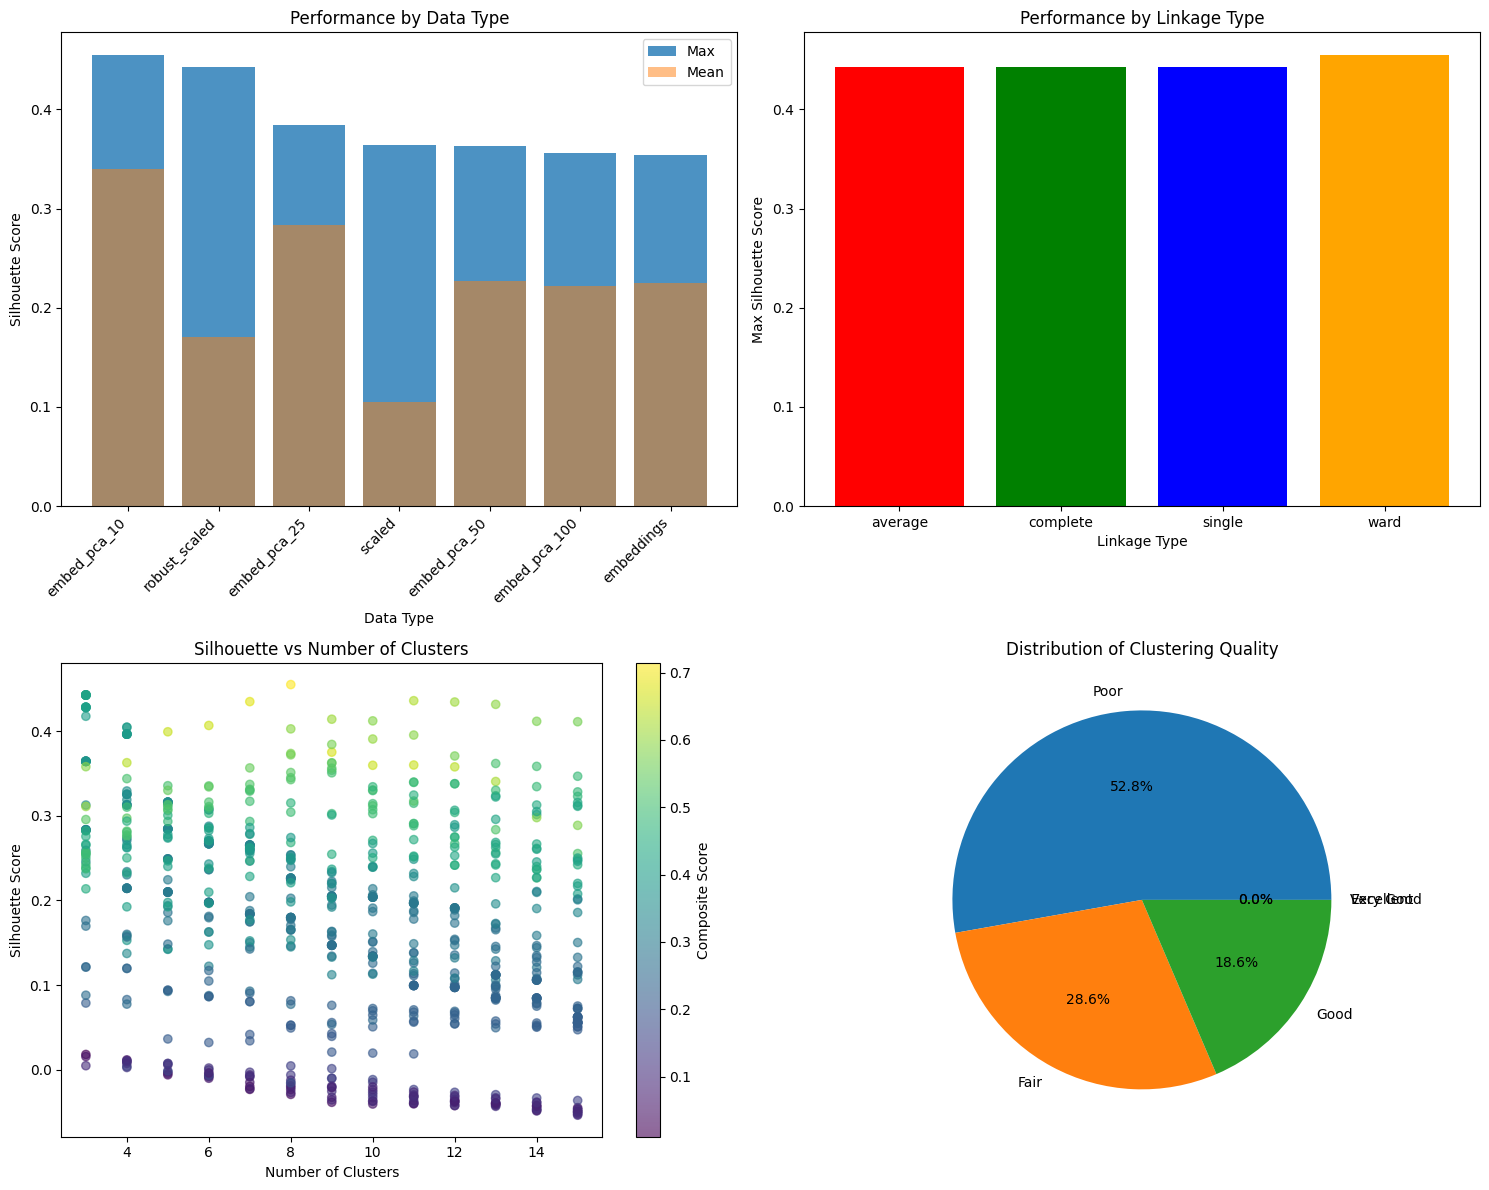


💾 Exporting results to: optimized_hierarchical_clustering_20250728_182611.xlsx
✅ Results exported successfully!

🎉 OPTIMIZED HIERARCHICAL CLUSTERING COMPLETE!
🏆 Best Silhouette Score: 0.4550
🎯 Best Configuration: embed_pca_10 + ward + none
🏷️  Number of Clusters: 8
📁 Results saved to: optimized_hierarchical_clustering_20250728_182611.xlsx

📋 FINAL SUMMARY:
   Total configurations tested: 754
   Best silhouette score: 0.4550
   Quality level: Good
   Friends clustered: 2,425
   Final clusters: 8


In [12]:
import pandas as pd
import numpy as np
import warnings
import itertools
from datetime import datetime
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from sentence_transformers import SentenceTransformer
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

class OptimizedHierarchicalClustering:
    """
    Comprehensive hierarchical clustering system with embeddings, 
    scaling, dimensionality reduction, and automatic optimization
    """
    
    def __init__(self):
        self.results = []
        self.best_config = None
        self.clustered_data = None
        self.feature_matrices = {}
        
    def load_and_prepare_data(self, file_path, id_col='Unique_ID'):
        """Load and prepare data"""
        
        print("📁 Loading data...")
        self.df = pd.read_excel(file_path)
        self.id_col = id_col
        self.feat_cols = [c for c in self.df.columns if c != id_col]
        
        print(f"✅ Loaded {len(self.df):,} rows with {len(self.feat_cols)} feature columns")
        return self.df
    
    def create_feature_matrices(self):
        """Create multiple feature representations"""
        
        print("\n🔧 Creating feature matrices...")
        
        # Matrix 1: Traditional scaled tabular data
        print("   📊 Creating scaled tabular features...")
        df_encoded = self.df.copy()
        for col in self.feat_cols:
            if df_encoded[col].dtype == 'object':
                df_encoded[col] = pd.factorize(df_encoded[col].fillna('Unknown'))[0]
            else:
                df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_encoded[self.feat_cols])
        self.feature_matrices['scaled'] = X_scaled
        
        # Matrix 2: Robust scaled features
        robust_scaler = RobustScaler()
        X_robust = robust_scaler.fit_transform(df_encoded[self.feat_cols])
        self.feature_matrices['robust_scaled'] = X_robust
        
        # Matrix 3: Sentence embeddings
        print("   🔤 Creating sentence embeddings...")
        self._create_embeddings()
        
        # Matrix 4-6: Dimensionality reduced embeddings
        print("   📉 Creating reduced embeddings...")
        self._create_reduced_embeddings()
        
        print(f"   ✅ Created {len(self.feature_matrices)} feature matrices")
        for name, matrix in self.feature_matrices.items():
            print(f"      {name}: {matrix.shape}")
    
    def _create_embeddings(self):
        """Create sentence embeddings from structured data"""
        
        # Create rich text descriptions
        sentences = []
        for _, row in self.df.iterrows():
            # Build comprehensive text representation
            parts = []
            if 'Parent_Industry' in row:
                parts.append(f"Professional in {row['Parent_Industry']} industry")
            if 'Job_Function' in row:
                parts.append(f"working as {row['Job_Function']}")
            if 'Job_Seniority' in row:
                parts.append(f"at {row['Job_Seniority']} level")
            if 'Turnover_Range' in row:
                parts.append(f"company with {row['Turnover_Range']} revenue")
            if 'Employees_Range' in row:
                parts.append(f"and {row['Employees_Range']} employees")
            
            # Add interests
            interests = []
            for i in range(1, 6):
                col = f'aoi_{i}'
                if col in row and pd.notna(row[col]):
                    interests.append(str(row[col]))
            
            if interests:
                parts.append(f"interested in {', '.join(interests)}")
            
            sentence = '. '.join(parts) + '.'
            sentences.append(sentence)
        
        # Generate embeddings
        model = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = model.encode(sentences, show_progress_bar=True, normalize_embeddings=True)
        
        self.feature_matrices['embeddings'] = embeddings
    
    def _create_reduced_embeddings(self):
        """Create dimensionality reduced versions of embeddings"""
        
        embeddings = self.feature_matrices['embeddings']
        
        # Different dimensionality reductions
        dimensions = [10, 25, 50, 100]
        
        for dim in dimensions:
            if dim < embeddings.shape[1]:
                pca = PCA(n_components=dim, random_state=42)
                X_reduced = pca.fit_transform(embeddings)
                self.feature_matrices[f'embed_pca_{dim}'] = X_reduced
                
                print(f"      PCA {dim}D: explained variance = {pca.explained_variance_ratio_.sum():.3f}")
    
    def comprehensive_hierarchical_search(self):
        """Comprehensive search across all configurations"""
        
        print(f"\n🔍 Starting comprehensive hierarchical clustering search...")
        
        # Configuration space
        linkage_types = ['complete', 'ward', 'average', 'single']
        connectivity_configs = [
            ('none', None),
            ('knn5', 5),
            ('knn8', 8),
            ('knn10', 10),
            ('knn15', 15),
            ('knn20', 20)
        ]
        k_range = range(3, 16)  # 3 to 15 clusters
        
        total_configs = len(self.feature_matrices) * len(linkage_types) * len(connectivity_configs) * len(k_range)
        print(f"   📊 Testing {total_configs:,} configurations...")
        
        # Progress tracking
        pbar = tqdm(total=total_configs, desc="Testing configurations")
        
        for data_name, X in self.feature_matrices.items():
            self._test_data_matrix(data_name, X, linkage_types, connectivity_configs, k_range, pbar)
        
        pbar.close()
        
        # Convert results to DataFrame
        self.results_df = pd.DataFrame(self.results, columns=[
            'data_type', 'linkage', 'connectivity', 'k', 'n_neighbors',
            'silhouette', 'calinski', 'davies', 'actual_clusters'
        ])
        
        # Add quality ratings
        self.results_df['quality'] = pd.cut(
            self.results_df['silhouette'],
            bins=[-1, 0.2, 0.3, 0.5, 0.7, 1.0],
            labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
        )
        
        # Calculate composite score
        self.results_df['composite_score'] = (
            0.5 * self.results_df['silhouette'] + 
            0.3 * (self.results_df['calinski'] / self.results_df['calinski'].max()) +
            0.2 * (1 - self.results_df['davies'] / self.results_df['davies'].max())
        )
        
        print(f"\n✅ Search complete! Found {len(self.results_df)} valid configurations")
        
        # Show top results
        top_10 = self.results_df.nlargest(10, 'silhouette')
        print(f"\n🏆 TOP 10 CONFIGURATIONS BY SILHOUETTE SCORE:")
        print(top_10[['data_type', 'linkage', 'connectivity', 'k', 'silhouette', 'quality']].to_string(index=False))
        
        return self.results_df
    
    def _test_data_matrix(self, data_name, X, linkage_types, connectivity_configs, k_range, pbar):
        """Test all configurations for a single data matrix"""
        
        for linkage in linkage_types:
            for conn_name, n_neighbors in connectivity_configs:
                # Skip incompatible combinations
                if linkage == 'ward' and conn_name != 'none':
                    pbar.update(len(k_range))
                    continue
                
                # Create connectivity matrix
                connectivity = None
                if conn_name != 'none':
                    try:
                        connectivity = kneighbors_graph(
                            X, n_neighbors=n_neighbors, include_self=False
                        )
                        
                        # Check if graph is connected
                        n_components, _ = connected_components(connectivity, directed=False)
                        if n_components > 1:
                            pbar.update(len(k_range))
                            continue
                            
                    except Exception:
                        pbar.update(len(k_range))
                        continue
                
                # Test different cluster numbers
                for k in k_range:
                    try:
                        # Fit clustering model
                        model = AgglomerativeClustering(
                            n_clusters=k,
                            linkage=linkage,
                            connectivity=connectivity
                        )
                        
                        labels = model.fit_predict(X)
                        actual_clusters = len(set(labels))
                        
                        # Calculate metrics only if we have multiple clusters
                        if actual_clusters >= 2:
                            sil_score = silhouette_score(X, labels)
                            cal_score = calinski_harabasz_score(X, labels)
                            dbi_score = davies_bouldin_score(X, labels)
                            
                            self.results.append([
                                data_name, linkage, conn_name, k, n_neighbors,
                                sil_score, cal_score, dbi_score, actual_clusters
                            ])
                    
                    except Exception:
                        pass
                    
                    pbar.update(1)
    
    def select_best_configuration(self):
        """Select and apply the best configuration"""
        
        if self.results_df is None or len(self.results_df) == 0:
            print("❌ No valid results found!")
            return None
        
        # Find best configuration by silhouette score
        best_idx = self.results_df['silhouette'].idxmax()
        self.best_config = self.results_df.iloc[best_idx]
        
        print(f"\n🏆 BEST CONFIGURATION SELECTED:")
        print(f"   Data Type: {self.best_config['data_type']}")
        print(f"   Linkage: {self.best_config['linkage']}")
        print(f"   Connectivity: {self.best_config['connectivity']}")
        print(f"   Clusters: {self.best_config['k']}")
        print(f"   Silhouette Score: {self.best_config['silhouette']:.4f}")
        print(f"   Quality: {self.best_config['quality']}")
        
        # Apply best configuration
        self._apply_best_configuration()
        
        return self.best_config
    
    def _apply_best_configuration(self):
        """Apply the best configuration to get final clusters"""
        
        # Get the feature matrix
        X = self.feature_matrices[self.best_config['data_type']]
        
        # Create connectivity if needed
        connectivity = None
        if self.best_config['connectivity'] != 'none':
            connectivity = kneighbors_graph(
                X, 
                n_neighbors=self.best_config['n_neighbors'], 
                include_self=False
            )
        
        # Fit final model
        final_model = AgglomerativeClustering(
            n_clusters=int(self.best_config['k']),
            linkage=self.best_config['linkage'],
            connectivity=connectivity
        )
        
        final_labels = final_model.fit_predict(X)
        
        # Add to original dataframe
        self.clustered_data = self.df.copy()
        self.clustered_data['cluster_id'] = final_labels
        self.clustered_data['silhouette_score'] = self.best_config['silhouette']
        self.clustered_data['clustering_method'] = f"{self.best_config['data_type']}_{self.best_config['linkage']}_{self.best_config['connectivity']}"
        
        print(f"✅ Applied best configuration to {len(self.clustered_data)} friends")
        
        # Show cluster distribution
        cluster_counts = pd.Series(final_labels).value_counts().sort_index()
        print(f"\n📊 Cluster Distribution:")
        for cluster_id, count in cluster_counts.items():
            percentage = (count / len(final_labels)) * 100
            print(f"   Cluster {cluster_id}: {count} friends ({percentage:.1f}%)")
    
    def analyze_clusters(self):
        """Analyze the characteristics of each cluster"""
        
        if self.clustered_data is None:
            print("❌ No clustered data available!")
            return None
        
        print(f"\n🔍 CLUSTER ANALYSIS:")
        print("=" * 60)
        
        cluster_profiles = {}
        
        for cluster_id in sorted(self.clustered_data['cluster_id'].unique()):
            cluster_data = self.clustered_data[self.clustered_data['cluster_id'] == cluster_id]
            cluster_size = len(cluster_data)
            percentage = (cluster_size / len(self.clustered_data)) * 100
            
            print(f"\n🏷️  Cluster {cluster_id}: {cluster_size} friends ({percentage:.1f}%)")
            
            profile = {
                'cluster_id': cluster_id,
                'size': cluster_size,
                'percentage': percentage
            }
            
            # Analyze categorical features
            categorical_cols = ['Parent_Industry', 'Job_Function', 'Job_Seniority', 
                              'Turnover_Range', 'Employees_Range']
            
            for col in categorical_cols:
                if col in cluster_data.columns:
                    mode_value = cluster_data[col].mode()
                    if len(mode_value) > 0:
                        count = (cluster_data[col] == mode_value.iloc[0]).sum()
                        pct = (count / cluster_size) * 100
                        if pct > 25:  # Only show if significant
                            print(f"   • {col}: {mode_value.iloc[0]} ({pct:.1f}%)")
                        profile[f'{col}_dominant'] = mode_value.iloc[0]
                        profile[f'{col}_dominance_pct'] = pct
            
            # Analyze interests
            interest_cols = ['aoi_1', 'aoi_2', 'aoi_3', 'aoi_4', 'aoi_5']
            all_interests = []
            for col in interest_cols:
                if col in cluster_data.columns:
                    all_interests.extend(cluster_data[col].dropna().tolist())
            
            if all_interests:
                interest_counts = pd.Series(all_interests).value_counts().head(3)
                top_interests = interest_counts.index.tolist()
                print(f"   • Top Interests: {', '.join(top_interests)}")
                profile['top_interests'] = top_interests
            
            # Sample friends
            sample_ids = cluster_data[self.id_col].head(3).tolist()
            print(f"   • Sample Friends: {', '.join(sample_ids)}")
            
            cluster_profiles[cluster_id] = profile
        
        return cluster_profiles
    
    def visualize_results(self):
        """Create visualizations of clustering results"""
        
        print("\n📊 Creating visualizations...")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Performance by data type
        data_performance = self.results_df.groupby('data_type')['silhouette'].agg(['max', 'mean']).sort_values('max', ascending=False)
        bars1 = axes[0,0].bar(range(len(data_performance)), data_performance['max'], alpha=0.8, label='Max')
        axes[0,0].bar(range(len(data_performance)), data_performance['mean'], alpha=0.5, label='Mean')
        axes[0,0].set_title('Performance by Data Type')
        axes[0,0].set_xlabel('Data Type')
        axes[0,0].set_ylabel('Silhouette Score')
        axes[0,0].set_xticks(range(len(data_performance)))
        axes[0,0].set_xticklabels(data_performance.index, rotation=45, ha='right')
        axes[0,0].legend()
        
        # 2. Performance by linkage
        linkage_performance = self.results_df.groupby('linkage')['silhouette'].agg(['max', 'mean'])
        axes[0,1].bar(range(len(linkage_performance)), linkage_performance['max'], color=['red', 'green', 'blue', 'orange'][:len(linkage_performance)])
        axes[0,1].set_title('Performance by Linkage Type')
        axes[0,1].set_xlabel('Linkage Type')
        axes[0,1].set_ylabel('Max Silhouette Score')
        axes[0,1].set_xticks(range(len(linkage_performance)))
        axes[0,1].set_xticklabels(linkage_performance.index)
        
        # 3. Silhouette vs Number of Clusters
        scatter = axes[1,0].scatter(self.results_df['k'], self.results_df['silhouette'], 
                                   c=self.results_df['composite_score'], cmap='viridis', alpha=0.6)
        axes[1,0].set_xlabel('Number of Clusters')
        axes[1,0].set_ylabel('Silhouette Score')
        axes[1,0].set_title('Silhouette vs Number of Clusters')
        plt.colorbar(scatter, ax=axes[1,0], label='Composite Score')
        
        # 4. Quality distribution
        quality_counts = self.results_df['quality'].value_counts()
        axes[1,1].pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%')
        axes[1,1].set_title('Distribution of Clustering Quality')
        
        plt.tight_layout()
        plt.show()
    
    def export_results(self, output_filename=None):
        """Export all results to Excel"""
        
        if output_filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_filename = f'optimized_hierarchical_clustering_{timestamp}.xlsx'
        
        print(f"\n💾 Exporting results to: {output_filename}")
        
        with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
            # Clustered data
            if self.clustered_data is not None:
                self.clustered_data.to_excel(writer, sheet_name='Clustered_Friends', index=False)
            
            # All results leaderboard
            self.results_df.sort_values('silhouette', ascending=False).to_excel(
                writer, sheet_name='Results_Leaderboard', index=False
            )
            
            # Best configuration details
            if self.best_config is not None:
                best_config_df = pd.DataFrame([self.best_config]).T
                best_config_df.columns = ['Value']
                best_config_df.to_excel(writer, sheet_name='Best_Configuration')
            
            # Performance summaries
            data_summary = self.results_df.groupby('data_type').agg({
                'silhouette': ['max', 'mean', 'std'],
                'k': 'mean'
            }).round(4)
            data_summary.to_excel(writer, sheet_name='Data_Type_Performance')
            
            linkage_summary = self.results_df.groupby('linkage').agg({
                'silhouette': ['max', 'mean', 'std'],
                'k': 'mean'
            }).round(4)
            linkage_summary.to_excel(writer, sheet_name='Linkage_Performance')
        
        print(f"✅ Results exported successfully!")
        return output_filename

# Main execution function
def run_optimized_hierarchical_clustering(file_path):
    """
    Complete optimized hierarchical clustering pipeline
    """
    
    print("🚀 OPTIMIZED HIERARCHICAL CLUSTERING PIPELINE")
    print("=" * 60)
    
    # Initialize system
    clustering_system = OptimizedHierarchicalClustering()
    
    # Load data
    clustering_system.load_and_prepare_data(file_path)
    
    # Create feature matrices
    clustering_system.create_feature_matrices()
    
    # Comprehensive search
    results_df = clustering_system.comprehensive_hierarchical_search()
    
    # Select best configuration
    best_config = clustering_system.select_best_configuration()
    
    if best_config is None:
        print("❌ No valid configurations found!")
        return None
    
    # Analyze clusters
    cluster_profiles = clustering_system.analyze_clusters()
    
    # Create visualizations
    clustering_system.visualize_results()
    
    # Export results
    output_file = clustering_system.export_results()
    
    print(f"\n🎉 OPTIMIZED HIERARCHICAL CLUSTERING COMPLETE!")
    print(f"🏆 Best Silhouette Score: {best_config['silhouette']:.4f}")
    print(f"🎯 Best Configuration: {best_config['data_type']} + {best_config['linkage']} + {best_config['connectivity']}")
    print(f"🏷️  Number of Clusters: {best_config['k']}")
    print(f"📁 Results saved to: {output_file}")
    
    return clustering_system, best_config, output_file

# Run the complete pipeline
if __name__ == "__main__":
    clustering_system, best_config, output_file = run_optimized_hierarchical_clustering('./las3.18.xlsx')
    
    if clustering_system:
        print(f"\n📋 FINAL SUMMARY:")
        print(f"   Total configurations tested: {len(clustering_system.results_df):,}")
        print(f"   Best silhouette score: {best_config['silhouette']:.4f}")
        print(f"   Quality level: {best_config['quality']}")
        print(f"   Friends clustered: {len(clustering_system.clustered_data):,}")
        print(f"   Final clusters: {best_config['k']}")
